# Importing Modules

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.8.0

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
import pickle as pic
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error

# Data Setting

In [ ]:
df = pd.read_csv("/content/Data.csv")

#Data Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Employee_ID                  9999 non-null   int64  
 1   Department                   9999 non-null   object 
 2   Gender                       9999 non-null   object 
 3   Age                          9999 non-null   int64  
 4   Job_Title                    9999 non-null   object 
 5   Hire_Date                    9999 non-null   object 
 6   Years_At_Company             9999 non-null   int64  
 7   Education_Level              9999 non-null   object 
 8   Performance_Score            9999 non-null   int64  
 9   Monthly_Salary               9999 non-null   int64  
 10  Work_Hours_Per_Week          9999 non-null   int64  
 11  Projects_Handled             9999 non-null   int64  
 12  Overtime_Hours               9999 non-null   int64  
 13  Sick_Days         

In [ ]:
df.head(10)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,03:05.6,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,03:05.6,0,High School,5,75000,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,03:05.6,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,03:05.6,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,03:05.6,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25,False
5,6,IT,Male,43,Manager,03:05.6,8,High School,3,78000,46,31,8,0,100,15,95,0,2.77,False
6,7,IT,Male,37,Technician,03:05.6,1,Bachelor,5,52500,55,20,29,2,0,16,27,0,4.46,False
7,8,Engineering,Female,55,Engineer,03:05.6,9,Bachelor,2,72000,42,46,7,8,100,7,64,0,2.09,False
8,9,Marketing,Female,55,Technician,03:05.6,1,High School,2,42000,51,23,21,14,0,1,0,1,1.44,False
9,10,Engineering,Female,45,Consultant,03:05.6,7,Bachelor,1,60500,41,33,2,6,75,4,53,2,2.93,False


In [ ]:
df.tail(10)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
9989,9990,Finance,Female,33,Technician,03:05.6,7,High School,4,49000,52,32,24,10,0,4,92,1,1.07,False
9990,9991,Engineering,Male,26,Technician,03:05.6,1,Master,3,45500,52,3,1,5,25,13,73,0,3.64,False
9991,9992,IT,Female,39,Analyst,03:05.6,3,Bachelor,1,44000,38,3,5,0,25,5,6,0,2.06,False
9992,9993,Engineering,Female,47,Developer,03:05.6,1,Bachelor,3,65000,57,29,21,9,100,16,1,0,3.66,False
9993,9994,Operations,Female,57,Analyst,03:05.6,7,High School,1,44000,59,14,8,8,0,18,65,0,3.35,False
9994,9995,Operations,Female,27,Developer,03:05.6,9,Bachelor,4,70000,56,47,7,14,0,1,45,2,3.71,False
9995,9996,IT,Female,22,Developer,03:05.6,5,High School,5,75000,60,2,12,11,25,2,99,1,2.71,False
9996,9997,HR,Female,35,Specialist,03:05.6,8,Bachelor,5,67500,51,35,15,1,0,4,51,1,1.71,False
9997,9998,IT,Male,26,Analyst,03:05.6,0,Bachelor,2,48000,40,23,10,11,100,12,13,1,4.42,False
9998,9999,Finance,Male,38,Analyst,03:05.6,5,Bachelor,5,60000,32,31,22,6,50,2,55,0,1.11,False


In [ ]:
df.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000,9999.000000
mean,5000.000000,40.918792,4.522752,2.997700,64048.804880,45.094309,24.329633,14.530253,7.004500,49.959996,9.979898,49.024602,1.000400,2.993531
std,2886.607005,11.198745,2.844235,1.418061,13742.788697,8.932344,14.361741,8.658837,4.349467,35.328785,5.471973,28.914315,0.814452,1.145399
min,1.000000,22.000000,0.000000,1.000000,38500.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,2500.500000,31.000000,2.000000,2.000000,52500.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,24.000000,0.000000,2.010000
50%,5000.000000,41.000000,5.000000,3.000000,65000.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,2.980000
75%,7499.500000,51.000000,7.000000,4.000000,75000.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,74.000000,2.000000,3.990000
max,9999.000000,60.000000,10.000000,5.000000,90000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.head(5)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,03:05.6,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,03:05.6,0,High School,5,75000,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,03:05.6,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,03:05.6,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,03:05.6,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25,False


In [ ]:
df.shape

(9999, 20)

## Features Engineering

In [ ]:
# Droping the "Employee_ID"
# It is Not Important in Model Training
df.drop(["Employee_ID"], axis = "columns", inplace = True)

In [ ]:
df.columns.to_list()

['Department',
 'Gender',
 'Age',
 'Job_Title',
 'Hire_Date',
 'Years_At_Company',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Sick_Days',
 'Remote_Work_Frequency',
 'Team_Size',
 'Training_Hours',
 'Promotions',
 'Employee_Satisfaction_Score',
 'Resigned']

In [ ]:
# Removing "Resigned" on the Basis of Model to Not Cheat
df.drop(["Resigned"], axis = "columns", inplace = True)

In [ ]:
df["Hire_Date"] = pd.to_datetime(df["Hire_Date"], errors="coerce")

In [ ]:
df["Hire_Year"] = df["Hire_Date"].dt.year

In [ ]:
df["Hire_Date"].dtype


dtype('<M8[ns]')

In [ ]:
df = df.reset_index()
df["Hire_Year"] = df["Hire_Date"].dt.year


In [ ]:
df = df.drop(["index"], axis = 1)

In [ ]:
df.Hire_Year.head()

,Hire_Year
0,2026
1,2026
2,2026
3,2026
4,2026


In [ ]:
df["Hire_Month"] = df["Hire_Date"].dt.month


In [ ]:
df.Hire_Month.head()

,Hire_Month
0,4
1,4
2,4
3,4
4,4


In [ ]:
df[["Hire_Year", "Hire_Month"]].describe()


,Hire_Year,Hire_Month
count,9999.0,9999.0
mean,2026.0,4.0
std,0.0,0.0
min,2026.0,4.0
25%,2026.0,4.0
50%,2026.0,4.0
75%,2026.0,4.0
max,2026.0,4.0


In [ ]:
df = df.drop(["Hire_Year", "Hire_Month"], axis = 1)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2026-04-10 03:05:36,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,29,Developer,2026-04-10 03:05:36,0,High School,5,75000,34,34,13,14,100,12,61,2,1.72
2,Finance,Male,55,Specialist,2026-04-10 03:05:36,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,2026-04-10 03:05:36,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,2026-04-10 03:05:36,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25


In [ ]:
df = df.drop(["Hire_Date"], axis = 1)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,29,Developer,0,High School,5,75000,34,34,13,14,100,12,61,2,1.72
2,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25


In [ ]:
df.isnull().sum()

,0
Department,0
Gender,0
Age,0
Job_Title,0
Years_At_Company,0
Education_Level,0
Performance_Score,0
Monthly_Salary,0
Work_Hours_Per_Week,0
Projects_Handled,0


In [ ]:
df.columns.to_list()

['Department',
 'Gender',
 'Age',
 'Job_Title',
 'Years_At_Company',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Sick_Days',
 'Remote_Work_Frequency',
 'Team_Size',
 'Training_Hours',
 'Promotions',
 'Employee_Satisfaction_Score']

In [ ]:
df.Performance_Score.value_counts()

,count
Performance_Score,
5,2027
1,2011
3,2008
2,2004
4,1949


#Outliers Checking

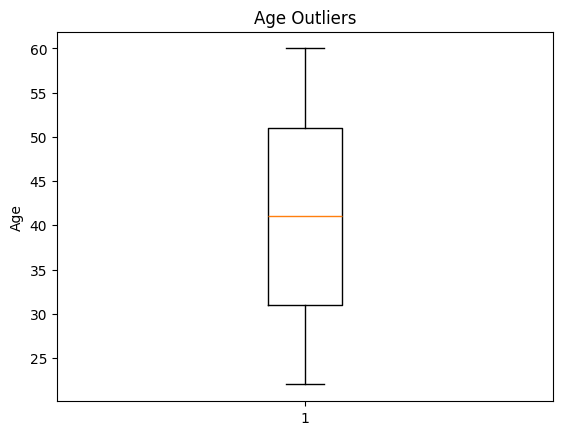

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Age"])
plt.title("Age Outliers")
plt.ylabel("Age")
plt.show()


In [ ]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound


age_outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]
age_outliers.shape


(0, 17)

In [ ]:
age_outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]
age_outliers.shape


(0, 17)

## Years_At_Company

In [ ]:

IQR = Q3 - Q1
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

Q1 = df["Years_At_Company"].quantile(0.25)
Q3 = df["Years_At_Company"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-5.5), np.float64(14.5))

In [ ]:
tenure_outliers = df[
    (df["Years_At_Company"] < lower) |
    (df["Years_At_Company"] > upper)
]

tenure_outliers.shape


(0, 17)

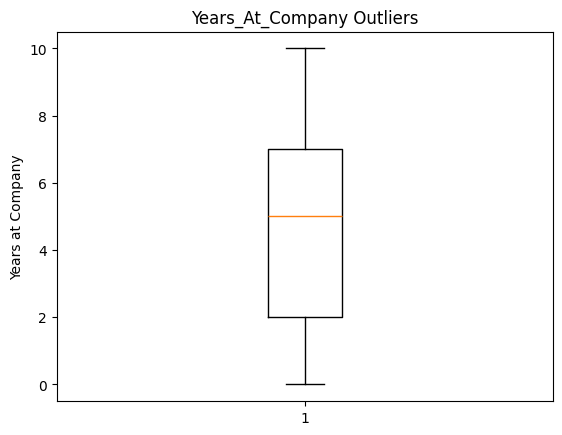

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Years_At_Company"])
plt.title("Years_At_Company Outliers")
plt.ylabel("Years at Company")
plt.show()


In [ ]:

df = df[df["Years_At_Company"] >= 0]


In [ ]:
df.shape

(9999, 17)

In [ ]:
df

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,29,Developer,0,High School,5,75000,34,34,13,14,100,12,61,2,1.72
2,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,Operations,Female,27,Developer,9,Bachelor,4,70000,56,47,7,14,0,1,45,2,3.71
9995,IT,Female,22,Developer,5,High School,5,75000,60,2,12,11,25,2,99,1,2.71
9996,HR,Female,35,Specialist,8,Bachelor,5,67500,51,35,15,1,0,4,51,1,1.71
9997,IT,Male,26,Analyst,0,Bachelor,2,48000,40,23,10,11,100,12,13,1,4.42


In [ ]:
df = df[
    (df["Years_At_Company"] >= 0) &
    (df["Years_At_Company"] <= 14.5)
]


In [ ]:
df["Years_At_Company"].describe()


,Years_At_Company
count,9999.000000
mean,4.522752
std,2.844235
min,0.000000
25%,2.000000
50%,5.000000
75%,7.000000
max,10.000000


In [ ]:
df = df[df["Years_At_Company"] > 0]


In [ ]:
df = df[
    (df["Years_At_Company"] > 0) &
    (df["Years_At_Company"] <= 14.5)
]


In [ ]:
df["Years_At_Company"].describe()


,Years_At_Company
count,9019.000000
mean,5.014192
std,2.550362
min,1.000000
25%,3.000000
50%,5.000000
75%,7.000000
max,10.000000


In [ ]:
df.shape

(9019, 17)

In [ ]:
(df["Years_At_Company"] == 0).sum()


np.int64(0)

## Monthly Salary

In [ ]:
IQR = Q3 - Q1
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

Q1 = df["Monthly_Salary"].quantile(0.25)
Q3 = df["Monthly_Salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(18750.0), np.float64(108750.0))

In [ ]:
salary_outliers = df[
    (df["Monthly_Salary"] < lower) |
    (df["Monthly_Salary"] > upper)
]

salary_outliers.shape


(0, 17)

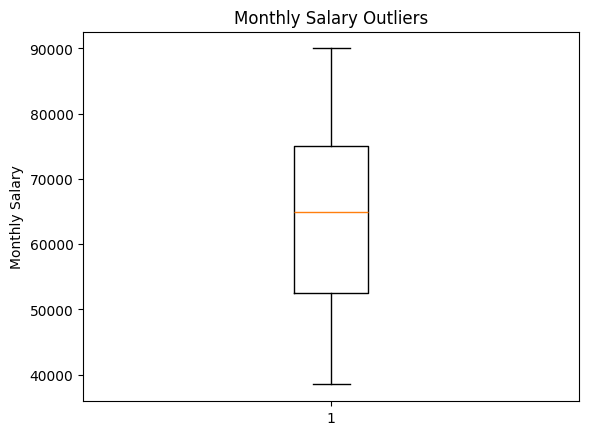

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Monthly_Salary"])
plt.title("Monthly Salary Outliers")
plt.ylabel("Monthly Salary")
plt.show()


In [ ]:
df["Monthly_Salary"].describe()
df.shape


(9019, 17)

In [ ]:
df[
    (df["Monthly_Salary"] < lower) |
    (df["Monthly_Salary"] > upper)
].shape


(0, 17)

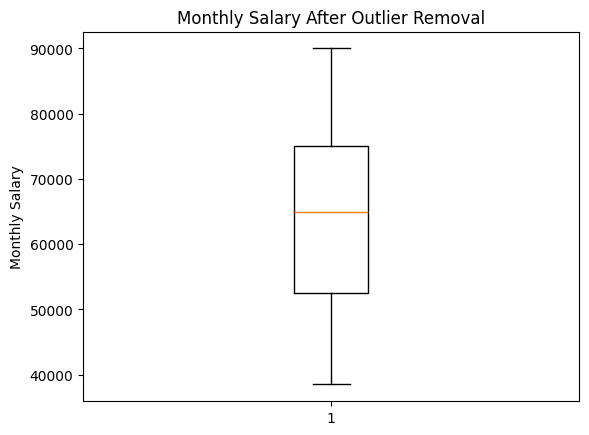

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Monthly_Salary"])
plt.title("Monthly Salary After Outlier Removal")
plt.ylabel("Monthly Salary")
plt.show()


In [ ]:
(df["Monthly_Salary"] < lower).sum() == 0
(df["Monthly_Salary"] > upper).sum() == 0


np.True_

In [ ]:
df.columns.to_list()

['Department',
 'Gender',
 'Age',
 'Job_Title',
 'Years_At_Company',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Sick_Days',
 'Remote_Work_Frequency',
 'Team_Size',
 'Training_Hours',
 'Promotions',
 'Employee_Satisfaction_Score']

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
2,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
3,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
4,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25
5,IT,Male,43,Manager,8,High School,3,78000,46,31,8,0,100,15,95,0,2.77


In [ ]:
df = df.reset_index()

In [ ]:
df = df.drop(["index"], axis = 1)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
2,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
3,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25
4,IT,Male,43,Manager,8,High School,3,78000,46,31,8,0,100,15,95,0,2.77


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Department                   9019 non-null   object 
 1   Gender                       9019 non-null   object 
 2   Age                          9019 non-null   int64  
 3   Job_Title                    9019 non-null   object 
 4   Years_At_Company             9019 non-null   int64  
 5   Education_Level              9019 non-null   object 
 6   Performance_Score            9019 non-null   int64  
 7   Monthly_Salary               9019 non-null   int64  
 8   Work_Hours_Per_Week          9019 non-null   int64  
 9   Projects_Handled             9019 non-null   int64  
 10  Overtime_Hours               9019 non-null   int64  
 11  Sick_Days                    9019 non-null   int64  
 12  Remote_Work_Frequency        9019 non-null   int64  
 13  Team_Size         


## Performance_Score

In [ ]:
df["Performance_Score"].unique()

array([5, 3, 2, 1, 4])

In [ ]:
df["Performance_Score"].value_counts().sort_index()

,count
Performance_Score,
1,1828
2,1791
3,1810
4,1775
5,1815


In [ ]:
invalid_perf = df[
    (df["Performance_Score"] < 1) |
    (df["Performance_Score"] > 5)
]

invalid_perf.shape


(0, 17)

In [ ]:
df["Performance_Score"].isna().sum()


np.int64(0)

## Work_Hours_Per_Week

In [ ]:
df["Work_Hours_Per_Week"].describe()


,Work_Hours_Per_Week
count,9019.000000
mean,45.084267
std,8.959100
min,30.000000
25%,37.000000
50%,45.000000
75%,53.000000
max,60.000000


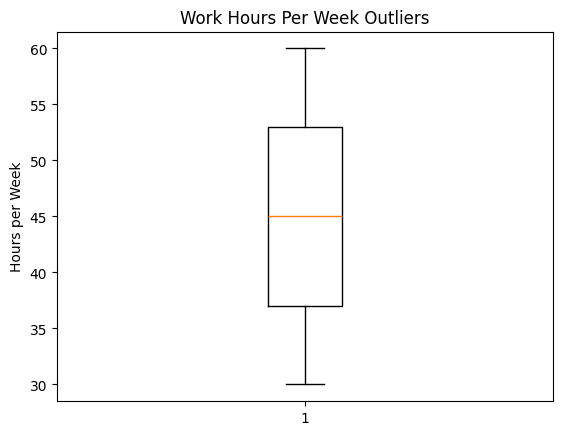

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Work_Hours_Per_Week"])
plt.title("Work Hours Per Week Outliers")
plt.ylabel("Hours per Week")
plt.show()

In [ ]:
Q1 = df["Work_Hours_Per_Week"].quantile(0.25)
Q3 = df["Work_Hours_Per_Week"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(13.0), np.float64(77.0))

In [ ]:
workhour_outliers = df[
    (df["Work_Hours_Per_Week"] < lower) |
    (df["Work_Hours_Per_Week"] > upper)
]

workhour_outliers.shape


(0, 17)

In [ ]:
df = df[
    (df["Work_Hours_Per_Week"] >= 20) &
    (df["Work_Hours_Per_Week"] <= 70)
]


## Projects Handled

In [ ]:
df["Projects_Handled"].describe()


,Projects_Handled
count,9019.000000
mean,24.343497
std,14.330238
min,0.000000
25%,12.000000
50%,24.000000
75%,37.000000
max,49.000000


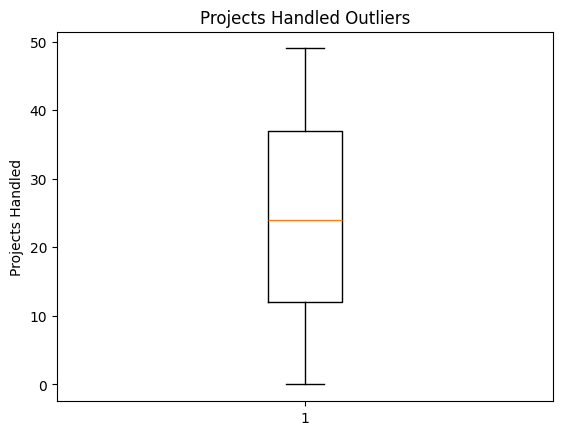

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Projects_Handled"])
plt.title("Projects Handled Outliers")
plt.ylabel("Projects Handled")
plt.show()


In [ ]:
Q1 = df["Projects_Handled"].quantile(0.25)
Q3 = df["Projects_Handled"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-25.5), np.float64(74.5))

In [ ]:
proj_outliers = df[
    (df["Projects_Handled"] < lower) |
    (df["Projects_Handled"] > upper)
]

proj_outliers.shape


(0, 17)

In [ ]:
df = df[df["Projects_Handled"] >= 0]

In [ ]:
df.shape

(9019, 17)

In [ ]:

(df["Projects_Handled"] < 0).sum()


np.int64(0)

In [ ]:
df["Projects_Handled"].describe()


,Projects_Handled
count,9019.000000
mean,24.343497
std,14.330238
min,0.000000
25%,12.000000
50%,24.000000
75%,37.000000
max,49.000000


In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
2,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
3,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25
4,IT,Male,43,Manager,8,High School,3,78000,46,31,8,0,100,15,95,0,2.77


## Overtime_Hours

In [ ]:
df["Overtime_Hours"].describe()


,Overtime_Hours
count,9019.000000
mean,14.538086
std,8.652976
min,0.000000
25%,7.000000
50%,15.000000
75%,22.000000
max,29.000000


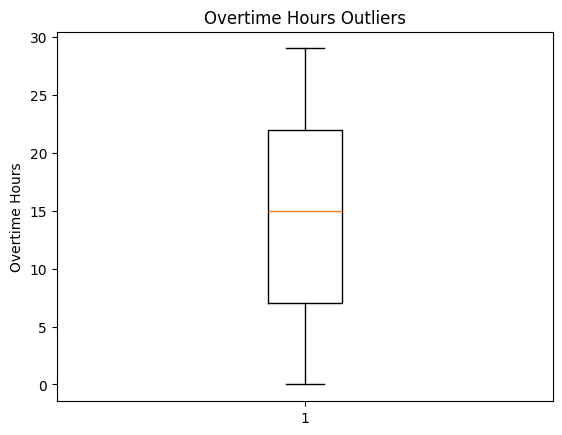

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Overtime_Hours"])
plt.title("Overtime Hours Outliers")
plt.ylabel("Overtime Hours")
plt.show()


In [ ]:
Q1 = df["Overtime_Hours"].quantile(0.25)
Q3 = df["Overtime_Hours"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-15.5), np.float64(44.5))

In [ ]:

ot_outliers = df[
    (df["Overtime_Hours"] < lower) |
    (df["Overtime_Hours"] > upper)
]

ot_outliers.shape


(0, 17)

In [ ]:
df = df[
    (df["Overtime_Hours"] >= 0) &
    (df["Overtime_Hours"] <= upper)
]


## Sick Days

In [ ]:
df["Sick_Days"].describe()

,Sick_Days
count,9019.000000
mean,6.981040
std,4.351028
min,0.000000
25%,3.000000
50%,7.000000
75%,11.000000
max,14.000000


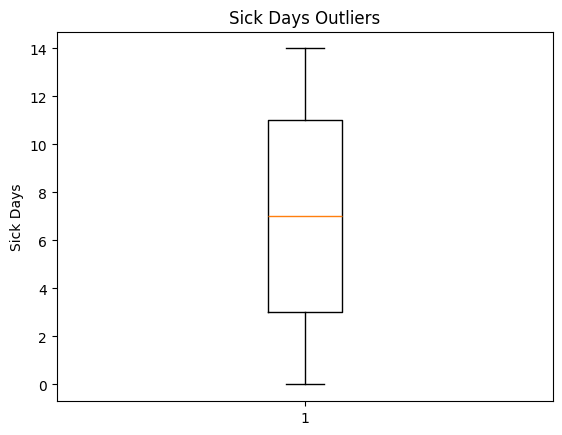

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df["Sick_Days"])
plt.title("Sick Days Outliers")
plt.ylabel("Sick Days")
plt.show()


In [ ]:

Q1 = df["Sick_Days"].quantile(0.25)
Q3 = df["Sick_Days"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-9.0), np.float64(23.0))

In [ ]:
sick_outliers = df[
    (df["Sick_Days"] < lower) |
    (df["Sick_Days"] > upper)
]

sick_outliers.shape

(0, 17)

In [ ]:

df = df[
    (df["Sick_Days"] >= 0) &
    (df["Sick_Days"] <= upper)
]


## Remote Work

In [ ]:
df["Remote_Work_Frequency"].describe()


,Remote_Work_Frequency
count,9019.000000
mean,49.747755
std,35.329927
min,0.000000
25%,25.000000
50%,50.000000
75%,75.000000
max,100.000000


In [ ]:
sorted(df["Remote_Work_Frequency"].unique())


[np.int64(0), np.int64(25), np.int64(50), np.int64(75), np.int64(100)]

## Team_Size

In [ ]:
df["Team_Size"].describe()


,Team_Size
count,9019.000000
mean,9.987471
std,5.458076
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,19.000000


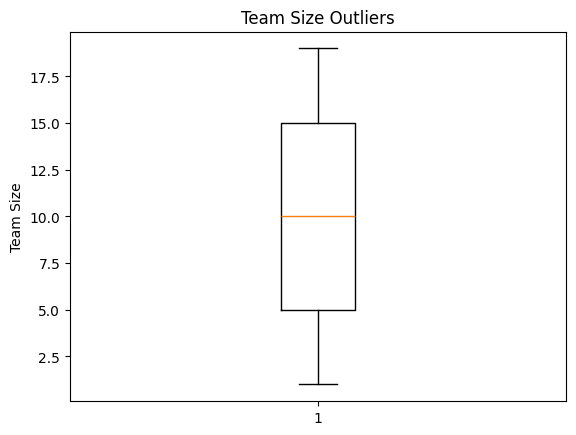

In [ ]:

import matplotlib.pyplot as plt

plt.boxplot(df["Team_Size"])
plt.title("Team Size Outliers")
plt.ylabel("Team Size")
plt.show()


In [ ]:
Q1 = df["Team_Size"].quantile(0.25)
Q3 = df["Team_Size"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper


(np.float64(-10.0), np.float64(30.0))

In [ ]:
team_outliers = df[
    (df["Team_Size"] < lower) |
    (df["Team_Size"] > upper)
]

team_outliers.shape


(0, 17)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,66,0,2.63
1,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,1,0,3.17
2,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,0,1,1.86
3,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,9,1,1.25
4,IT,Male,43,Manager,8,High School,3,78000,46,31,8,0,100,15,95,0,2.77


## Training_Hours

In [ ]:
df["Training_Hours"].describe()


,Training_Hours
count,9019.000000
mean,49.014081
std,28.972914
min,0.000000
25%,24.000000
50%,48.000000
75%,74.000000
max,99.000000


In [ ]:
df[["Training_Hours", "Performance_Score"]].corr()


,Training_Hours,Performance_Score
Training_Hours,1.000000,0.010211
Performance_Score,0.010211,1.000000


In [ ]:
df.drop("Training_Hours", axis = 1, inplace = True)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,2,0,14,0,2.63
1,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,3,50,10,0,3.17
2,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,12,100,10,1,1.86
3,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,13,100,15,1,1.25
4,IT,Male,43,Manager,8,High School,3,78000,46,31,8,0,100,15,0,2.77


# Correlation in Features

In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])
numeric_cols.columns


Index(['Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary',
       'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
       'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Promotions',
       'Employee_Satisfaction_Score'],
      dtype='object')

In [ ]:
corr_with_target = numeric_cols.corr()["Performance_Score"].sort_values(ascending=False)
corr_with_target


,Performance_Score
Performance_Score,1.000000
Monthly_Salary,0.518196
Projects_Handled,0.017888
Remote_Work_Frequency,0.015745
Employee_Satisfaction_Score,0.005111
Years_At_Company,0.001061
Age,-0.003044
Sick_Days,-0.004812
Overtime_Hours,-0.009221
Promotions,-0.018048


In [ ]:
df.drop(["Team_Size", "Sick_Days"], axis = 1, inplace = True)

In [ ]:
df.head()

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
0,IT,Male,55,Specialist,2,High School,5,67500,33,32,22,0,0,2.63
1,Finance,Male,55,Specialist,8,High School,3,58500,37,27,6,50,0,3.17
2,Customer Support,Female,48,Analyst,7,Bachelor,2,48000,52,10,28,100,1,1.86
3,Engineering,Female,36,Analyst,3,Bachelor,2,48000,38,11,29,100,1,1.25
4,IT,Male,43,Manager,8,High School,3,78000,46,31,8,100,0,2.77


In [ ]:
corr_matrix = numeric_cols.corr()
corr_matrix


,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Promotions,Employee_Satisfaction_Score
Age,1.000000,0.005183,-0.003044,0.007262,-0.010323,-0.012064,-0.000943,0.015983,0.008345,-0.010624,0.010437,0.029766
Years_At_Company,0.005183,1.000000,0.001061,0.004670,0.012813,0.018976,0.011442,0.014414,-0.001683,0.011548,-0.001127,0.007295
Performance_Score,-0.003044,0.001061,1.000000,0.518196,-0.019423,0.017888,-0.009221,-0.004812,0.015745,-0.022914,-0.018048,0.005111
Monthly_Salary,0.007262,0.004670,0.518196,1.000000,-0.014873,0.009079,-0.012451,-0.008832,-0.001713,0.005085,-0.015559,0.011311
Work_Hours_Per_Week,-0.010323,0.012813,-0.019423,-0.014873,1.000000,-0.001106,0.003027,-0.000662,-0.002630,-0.000613,-0.002989,0.011364
Projects_Handled,-0.012064,0.018976,0.017888,0.009079,-0.001106,1.000000,-0.004265,0.002262,0.001852,-0.000597,0.005105,-0.004124
Overtime_Hours,-0.000943,0.011442,-0.009221,-0.012451,0.003027,-0.004265,1.000000,0.006612,0.010591,-0.002663,0.007234,-0.002931
Sick_Days,0.015983,0.014414,-0.004812,-0.008832,-0.000662,0.002262,0.006612,1.000000,0.014504,-0.000085,-0.001153,-0.007040
Remote_Work_Frequency,0.008345,-0.001683,0.015745,-0.001713,-0.002630,0.001852,0.010591,0.014504,1.000000,-0.010238,-0.000859,0.004378
Team_Size,-0.010624,0.011548,-0.022914,0.005085,-0.000613,-0.000597,-0.002663,-0.000085,-0.010238,1.000000,0.003196,0.003358


In [ ]:
df.columns.to_list()

['Department',
 'Gender',
 'Age',
 'Job_Title',
 'Years_At_Company',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Remote_Work_Frequency',
 'Promotions',
 'Employee_Satisfaction_Score']

In [ ]:
df.drop("Gender", axis = 1, inplace = True)

In [ ]:
numeric_cols1 = df.select_dtypes(include=["int64", "float64"])
numeric_cols1.columns

Index(['Age', 'Years_At_Company', 'Performance_Score', 'Monthly_Salary',
       'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
       'Remote_Work_Frequency', 'Promotions', 'Employee_Satisfaction_Score'],
      dtype='object')

In [ ]:
corr_with_target1 = numeric_cols1.corr()["Performance_Score"].sort_values(ascending=False)
corr_with_target1

,Performance_Score
Performance_Score,1.000000
Monthly_Salary,0.518196
Projects_Handled,0.017888
Remote_Work_Frequency,0.015745
Employee_Satisfaction_Score,0.005111
Years_At_Company,0.001061
Age,-0.003044
Overtime_Hours,-0.009221
Promotions,-0.018048
Work_Hours_Per_Week,-0.019423


In [ ]:
corr_mat = numeric_cols1.corr()
corr_mat

,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
Age,1.000000,0.005183,-0.003044,0.007262,-0.010323,-0.012064,-0.000943,0.008345,0.010437,0.029766
Years_At_Company,0.005183,1.000000,0.001061,0.004670,0.012813,0.018976,0.011442,-0.001683,-0.001127,0.007295
Performance_Score,-0.003044,0.001061,1.000000,0.518196,-0.019423,0.017888,-0.009221,0.015745,-0.018048,0.005111
Monthly_Salary,0.007262,0.004670,0.518196,1.000000,-0.014873,0.009079,-0.012451,-0.001713,-0.015559,0.011311
Work_Hours_Per_Week,-0.010323,0.012813,-0.019423,-0.014873,1.000000,-0.001106,0.003027,-0.002630,-0.002989,0.011364
Projects_Handled,-0.012064,0.018976,0.017888,0.009079,-0.001106,1.000000,-0.004265,0.001852,0.005105,-0.004124
Overtime_Hours,-0.000943,0.011442,-0.009221,-0.012451,0.003027,-0.004265,1.000000,0.010591,0.007234,-0.002931
Remote_Work_Frequency,0.008345,-0.001683,0.015745,-0.001713,-0.002630,0.001852,0.010591,1.000000,-0.000859,0.004378
Promotions,0.010437,-0.001127,-0.018048,-0.015559,-0.002989,0.005105,0.007234,-0.000859,1.000000,0.019950
Employee_Satisfaction_Score,0.029766,0.007295,0.005111,0.011311,0.011364,-0.004124,-0.002931,0.004378,0.019950,1.000000


#Data Insights

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Department                   9019 non-null   object 
 1   Age                          9019 non-null   int64  
 2   Job_Title                    9019 non-null   object 
 3   Years_At_Company             9019 non-null   int64  
 4   Education_Level              9019 non-null   object 
 5   Performance_Score            9019 non-null   int64  
 6   Monthly_Salary               9019 non-null   int64  
 7   Work_Hours_Per_Week          9019 non-null   int64  
 8   Projects_Handled             9019 non-null   int64  
 9   Overtime_Hours               9019 non-null   int64  
 10  Remote_Work_Frequency        9019 non-null   int64  
 11  Promotions                   9019 non-null   int64  
 12  Employee_Satisfaction_Score  9019 non-null   float64
dtypes: float64(1), int

In [ ]:
df.columns.to_list()

['Department',
 'Age',
 'Job_Title',
 'Years_At_Company',
 'Education_Level',
 'Performance_Score',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Remote_Work_Frequency',
 'Promotions',
 'Employee_Satisfaction_Score']

In [ ]:
df.Department.unique()

array(['IT', 'Finance', 'Customer Support', 'Engineering', 'Marketing',
       'HR', 'Operations', 'Sales', 'Legal'], dtype=object)

In [ ]:
df.head()

,Department,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
0,IT,55,Specialist,2,High School,5,67500,33,32,22,0,0,2.63
1,Finance,55,Specialist,8,High School,3,58500,37,27,6,50,0,3.17
2,Customer Support,48,Analyst,7,Bachelor,2,48000,52,10,28,100,1,1.86
3,Engineering,36,Analyst,3,Bachelor,2,48000,38,11,29,100,1,1.25
4,IT,43,Manager,8,High School,3,78000,46,31,8,100,0,2.77


In [ ]:
df.groupby('Department')['Performance_Score'].mean()

,Performance_Score
Department,
Customer Support,2.985337
Engineering,3.017258
Finance,2.988956
HR,2.935834
IT,3.100917
Legal,2.973849
Marketing,2.932432
Operations,3.018627
Sales,3.008412


In [ ]:
df.Job_Title.unique()

array(['Specialist', 'Analyst', 'Manager', 'Technician', 'Engineer',
       'Consultant', 'Developer'], dtype=object)

In [ ]:
df.groupby('Job_Title')['Performance_Score'].mean()

,Performance_Score
Job_Title,
Analyst,2.982198
Consultant,3.022871
Developer,2.967963
Engineer,3.009732
Manager,3.036182
Specialist,2.964339
Technician,2.986614


In [ ]:

df.Education_Level.unique()

array(['High School', 'Bachelor', 'Master', 'PhD'], dtype=object)

In [ ]:
df.groupby("Education_Level")["Performance_Score"].mean()

,Performance_Score
Education_Level,
Bachelor,2.986426
High School,2.998891
Master,3.010271
PhD,3.017544


# Encoding to the Categorical Values

###### Department
###### Gender
###### Job_Title
###### Education_Level

In [ ]:
# # Department
# label_encoding = preprocessing.LabelEncoder()
# df["Department"] = label_encoding.fit_transform(df.Department)

# df = pd.get_dummies(df, columns = ["Department"], drop_first = True)

In [ ]:
x = df.drop("Performance_Score", axis = 1)
y = df.Performance_Score

# Get Dummies for Data

#Get Dummies

In [ ]:
df.head()

,Department,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
0,IT,55,Specialist,2,High School,5,67500,33,32,22,0,0,2.63
1,Finance,55,Specialist,8,High School,3,58500,37,27,6,50,0,3.17
2,Customer Support,48,Analyst,7,Bachelor,2,48000,52,10,28,100,1,1.86
3,Engineering,36,Analyst,3,Bachelor,2,48000,38,11,29,100,1,1.25
4,IT,43,Manager,8,High School,3,78000,46,31,8,100,0,2.77


In [ ]:
df_gd = df.copy()

In [ ]:
df_gd = pd.get_dummies(df_gd, columns = ["Department", "Job_Title", "Education_Level"], drop_first=True)

In [ ]:
df_gd.head()

,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,...,Department_Sales,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician,Education_Level_High School,Education_Level_Master,Education_Level_PhD
0,55,2,5,67500,33,32,22,0,0,2.63,...,False,False,False,False,False,True,False,True,False,False
1,55,8,3,58500,37,27,6,50,0,3.17,...,False,False,False,False,False,True,False,True,False,False
2,48,7,2,48000,52,10,28,100,1,1.86,...,False,False,False,False,False,False,False,False,False,False
3,36,3,2,48000,38,11,29,100,1,1.25,...,False,False,False,False,False,False,False,False,False,False
4,43,8,3,78000,46,31,8,100,0,2.77,...,False,False,False,False,True,False,False,True,False,False


In [ ]:
bool_cols = df_gd.select_dtypes(include = "bool").columns

df_gd[bool_cols] = df_gd[bool_cols].astype(int)

In [ ]:
df_gd.head()

,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,...,Department_Sales,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician,Education_Level_High School,Education_Level_Master,Education_Level_PhD
0,55,2,5,67500,33,32,22,0,0,2.63,...,0,0,0,0,0,1,0,1,0,0
1,55,8,3,58500,37,27,6,50,0,3.17,...,0,0,0,0,0,1,0,1,0,0
2,48,7,2,48000,52,10,28,100,1,1.86,...,0,0,0,0,0,0,0,0,0,0
3,36,3,2,48000,38,11,29,100,1,1.25,...,0,0,0,0,0,0,0,0,0,0
4,43,8,3,78000,46,31,8,100,0,2.77,...,0,0,0,0,1,0,0,1,0,0


In [ ]:
x = df_gd.drop("Performance_Score", axis = 1)
y = df_gd["Performance_Score"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 42)

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7215 entries, 8679 to 7270
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7215 non-null   int64  
 1   Years_At_Company             7215 non-null   int64  
 2   Monthly_Salary               7215 non-null   int64  
 3   Work_Hours_Per_Week          7215 non-null   int64  
 4   Projects_Handled             7215 non-null   int64  
 5   Overtime_Hours               7215 non-null   int64  
 6   Remote_Work_Frequency        7215 non-null   int64  
 7   Promotions                   7215 non-null   int64  
 8   Employee_Satisfaction_Score  7215 non-null   float64
 9   Department_Engineering       7215 non-null   int64  
 10  Department_Finance           7215 non-null   int64  
 11  Department_HR                7215 non-null   int64  
 12  Department_IT                7215 non-null   int64  
 13  Department_Legal    

In [ ]:
x_train.head()

,Age,Years_At_Company,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Department_Engineering,...,Department_Sales,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician,Education_Level_High School,Education_Level_Master,Education_Level_PhD
8679,30,5,38500,58,7,14,50,0,2.81,0,...,0,0,0,0,0,0,1,0,0,0
111,34,8,55000,56,6,3,0,0,4.65,0,...,0,0,1,0,0,0,0,1,0,0
8620,60,5,67500,40,5,28,0,2,1.26,0,...,0,0,0,0,0,1,0,0,0,1
6341,55,2,66000,38,45,0,25,1,1.58,0,...,0,0,0,0,1,0,0,0,0,0
3125,46,6,56000,40,25,17,75,2,2.63,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
x_train.Remote_Work_Frequency.unique()

array([ 50,   0,  25,  75, 100])

#Model --> Linear Regression

In [ ]:
modellr = LinearRegression()
modellr.fit(x_train, y_train)
modellr.score(x_train, y_train)

0.9676296559369938

In [ ]:
y_pred_train = modellr.predict(x_train)
y_pred_test = modellr.predict(x_test)

In [ ]:
modellr.score(x_test, y_pred_test)

1.0

In [ ]:
modellr.score(x_test, y_test)

0.9685346761153985

Error Metrics

mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

Mean Squared Error

In [ ]:
from sklearn.metrics import mean_squared_error

mse_train = mean_squared_error(y_train, y_pred_train)
print(f"mse_train: {mse_train}")

mse_test = mean_squared_error(y_test, y_pred_test)
print(f"mse_test: {mse_test}")

mse_train: 0.06482488697192397
mse_test: 0.06434343811991115


Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"mas_train: {mae_train}")

mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"mae_test: {mae_test}")

mas_train: 0.1887207569944874
mae_test: 0.18899101175409613


Root Mean Squared Error

In [ ]:
from sklearn.metrics import root_mean_squared_error

rmse_train = np.sqrt(root_mean_squared_error(y_train, y_pred_train))
print(f"rmse_train: {rmse_train}")

rmse_test = np.sqrt(root_mean_squared_error(y_test, y_pred_test))
print(f"rmse_test: {rmse_test}")

rmse_train: 0.5045862851525875
rmse_test: 0.503646784773604


r2_score

In [ ]:
from sklearn.metrics import r2_score

r2_train = r2_score(y_train, y_pred_train)
print(f"r2_Score_train: {r2_train}")

r2_test = r2_score(y_test, y_pred_test)
print(f"r2_Score_test: {r2_test}")

r2_Score_train: 0.9676296559369938
r2_Score_test: 0.9685346761153985


Mean Absolute Percentage Error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
print(f"mape_train: {mape_train}")

mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"mape_test: {mape_test}")

mape_train: 0.09923698102185942
mape_test: 0.09865916560410007


#Model --> Logistic Regression

In [ ]:
modellg = LogisticRegression(fit_intercept=True, max_iter=3000)
modellg.fit(x_train, y_train)
modellg.score(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.30145530145530147

In [ ]:
y_pred_train_log = modellg.predict(x_train)
y_pred_test_log  = modellg.predict(x_test)

In [ ]:
modellg.score(x_test, y_test)

0.3165188470066519

Metrics

Logistic Regression Metrics

Accuracy -- Measures overall correctness

Confusion Matrix -- True Positive (TP),
False Positive (FP),
True Negative (TN),
False Negative (FN).

Classification Report -- Precision,
Recall,
F1-score,
Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall


Function for Using Metrics for Logistic Regression

In [ ]:
def model_metric_train(metric, metric_name, y_train, y_pred_train_log):
  result = metric(y_train, y_pred_train_log)
  print(f"{metric_name}: {result}")

In [ ]:
def model_metric_test(metric, metric_name, y_test, y_pred_test_log):
  result = metric(y_test, y_pred_test_log)
  print(f"{metric_name}: {result}")

--> Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

model_metric_train(
    accuracy_score,
    "Accuracy_Score_train",
    y_train,
    y_pred_train_log,
)

model_metric_test(
    accuracy_score,
    "Accuracy_Score_test",
    y_test,
    y_pred_test_log
)

Accuracy_Score_train: 0.30145530145530147
Accuracy_Score_test: 0.3165188470066519


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

model_metric_train(
    confusion_matrix,
    "Confusion_matrix_train",
    y_train,
    y_pred_train_log,
)

model_metric_test(
    confusion_matrix,
    "Confusion_matrix_test",
    y_test,
    y_pred_test_log
)


Confusion_matrix_train: [[803 208 188 128 129]
 [573 198 158 199 309]
 [458 158 168 183 487]
 [258 142 172 196 660]
 [202 124 154 150 810]]
Confusion_matrix_test: [[212  50  40  37  33]
 [139  51  51  47  66]
 [ 99  44  58  43 112]
 [ 78  36  29  39 165]
 [ 47  23  44  50 211]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

model_metric_train(
    classification_report,
    "Classification_report_train",
    y_train,
    y_pred_train_log,
)

model_metric_test(
    classification_report,
    "Classification_report_test",
    y_test,
    y_pred_test_log
)


Classification_report_train:               precision    recall  f1-score   support

           1       0.35      0.55      0.43      1456
           2       0.24      0.14      0.17      1437
           3       0.20      0.12      0.15      1454
           4       0.23      0.14      0.17      1428
           5       0.34      0.56      0.42      1440

    accuracy                           0.30      7215
   macro avg       0.27      0.30      0.27      7215
weighted avg       0.27      0.30      0.27      7215

Classification_report_test:               precision    recall  f1-score   support

           1       0.37      0.57      0.45       372
           2       0.25      0.14      0.18       354
           3       0.26      0.16      0.20       356
           4       0.18      0.11      0.14       347
           5       0.36      0.56      0.44       375

    accuracy                           0.32      1804
   macro avg       0.28      0.31      0.28      1804
weighted avg       0

Precision

In [ ]:
from sklearn.metrics import precision_score

precision_score_train = precision_score(y_train, y_pred_train_log, average="weighted")
print(f"precision_score_train: {precision_score_train}")

precision_score_test = precision_score(y_test, y_pred_test_log, average='weighted')
print(f"precision_score_test: {precision_score_test}")


precision_score_train: 0.27127546167091016
precision_score_test: 0.2860932040432091


Recall

In [ ]:
from sklearn.metrics import recall_score

recall_train = recall_score(y_train, y_pred_train_log, average = 'weighted')
print(f"recall_train: {recall_train}")

recall_test = recall_score(y_test, y_pred_test_log, average = 'weighted')
print(f"recal_test: {recall_test}")

recall_train: 0.30145530145530147
recal_test: 0.3165188470066519


F1 Score

In [ ]:
from sklearn.metrics import f1_score

f1_train = f1_score(y_train, y_pred_train_log, average = 'weighted')
print(f"f1_train: {f1_train}")

f1_test = f1_score(y_test, y_pred_test_log, average = 'weighted')
print(f"f1_test: {f1_test}")

f1_train: 0.2690111663376183
f1_test: 0.2856358770973491


#RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor


model_rfr = RandomForestRegressor()
model_rfr.fit(x_train, y_train)
model_rfr.score(x_train, y_train)

1.0

In [ ]:
model_rfr.score(x_test, y_test)

1.0

Hyper Tuning for Random Forest Regressor

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
param_grid = {
              "n_estimators" : [200, 300, 400, 500, 600, 700, 800, 1000],
              "max_depth": [4, 5, 6, 7, 8, 9, 10, 12],
              "min_samples_leaf": range(2, 11),
              "min_samples_split": [2, 4, 5, 6, 8, 9, 10],
              # "max_leaf_nodes": range(4, 23),
              "max_features": range(3,8)
}

In [ ]:
param_grid1 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
hyper_rfr = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions = param_grid1, random_state=42)
hyper_rfr.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used her

In [ ]:
hyper_rfr.score(x_train, y_train)

0.9484032499068167

In [ ]:
hyper_rfr.score(x_test, y_test)

0.8881235470917666

In [ ]:
hyper_rfr.best_params_

{'n_estimators': 100,
 'min_samples_split': 10,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

In [ ]:
model_rfr = RandomForestRegressor(
    n_estimators = 100,
    min_samples_split = 10,
    min_samples_leaf = 2,
    max_features = 'sqrt',
    max_depth = None
)

model_rfr.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsa

In [ ]:
model_rfr.score(x_train, y_train)

0.9395399005260124

In [ ]:
model_rfr.score(x_test, y_test)

0.8705834689606148

Random Forest Regressor Metrics



mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

In [ ]:
y_pred_train_rfr = model_rfr.predict(x_train)
y_pred_test_rfr = model_rfr.predict(x_test)

In [ ]:
def rfr_train(metric, metric_name, y_train, y_pred_train_rfr):
  result = metric(y_train, y_pred_train_rfr)
  print(f"{metric_name}: {result}")

def rfr_test(metric, metric_name, y_test, y_pred_test_rfr):
  result = metric(y_test, y_pred_test_rfr)
  print(f"{metric_name}: {result}")

Mean Squared Error

In [ ]:
from sklearn.metrics import mean_squared_error

rfr_train(mean_squared_error, "mse_train", y_train, y_pred_train_rfr)

rfr_test(mean_squared_error, "mse_test", y_test, y_pred_test_rfr)

mse_train: 0.1210774623551695
mse_test: 0.2646438532514625


Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_absolute_error

rfr_train(mean_absolute_error, "mae_train", y_train, y_pred_train_rfr)

rfr_test(mean_absolute_error, "mae_test", y_test, y_pred_test_rfr)

mae_train: 0.27601217264382677
mae_test: 0.41134071597213223


Root Mean Squared Error

In [ ]:
from sklearn.metrics import root_mean_squared_error

rfr_train(root_mean_squared_error, "rmse_train", y_train, y_pred_train_rfr)

rfr_test(root_mean_squared_error, "rmse_test", y_test, y_pred_test_rfr)

rmse_train: 0.3479618691109264
rmse_test: 0.5144354704445082


r2 Score

In [ ]:
from sklearn.metrics import r2_score

rfr_train(r2_score, "r2_train", y_train, y_pred_train_rfr)

rfr_test(r2_score, "r2_test", y_test, y_pred_test_rfr)

r2_train: 0.9395399005260124
r2_test: 0.8705834689606148


Mean Absolute Percentage Error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

rfr_train(mean_absolute_percentage_error, "mape_train", y_train, y_pred_train_rfr)

rfr_test(mean_absolute_percentage_error, "mape_test", y_test, y_pred_test_rfr)

mape_train: 0.14353996981205536
mape_test: 0.21463471464324993


#Random Forest Classifier

In [ ]:
model_rd = RandomForestClassifier()
model_rd.fit(x_train, y_train)
model_rd.score(x_train, y_train)

1.0

In [ ]:
model_rd.score(x_test, y_test)

0.9955654101995566

In [ ]:
x_train.columns.to_list()

['Age',
 'Years_At_Company',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Remote_Work_Frequency',
 'Promotions',
 'Employee_Satisfaction_Score',
 'Department_Engineering',
 'Department_Finance',
 'Department_HR',
 'Department_IT',
 'Department_Legal',
 'Department_Marketing',
 'Department_Operations',
 'Department_Sales',
 'Job_Title_Consultant',
 'Job_Title_Developer',
 'Job_Title_Engineer',
 'Job_Title_Manager',
 'Job_Title_Specialist',
 'Job_Title_Technician',
 'Education_Level_High School',
 'Education_Level_Master',
 'Education_Level_PhD']

Hyper Tuning for Random Forest

Grid Search CV

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
param_grid = {
              "n_estimators" : [200, 300, 400, 500, 600, 700, 800, 1000],
              "max_depth": [4, 5, 6, 7, 8, 9, 10, 12],
              "min_samples_leaf": range(2, 11),
              "min_samples_split": [2, 4, 5, 6, 8, 9, 10],
              # "max_leaf_nodes": range(4, 23),
              "max_features": range(3,8)
}

In [ ]:
param_grid1 = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

In [ ]:
# hyper_rfc_gr = GridSearchCV(
#     estimator = RandomForestClassifier(random_state=42),
#     param_grid = param_grid1,
#     cv = 5,
#     n_jobs = 1,
#     verbose = 2
#     )
# hyper_rfc_gr.fit(x_train, y_train)

In [ ]:
# hyper_rfc_gr.score(x_train, y_train)

In [ ]:
# hyper_rfc_gr.score(x_test, y_test)

Randoomized Search CV

In [ ]:
hyper_rfc = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions = param_grid1, random_state=42)
hyper_rfc.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchange

In [ ]:
print(hyper_rfc.score(x_train, y_train))
print(hyper_rfc.score(x_test, y_test))

1.0
0.9988913525498891


In [ ]:
hyper_rfc.best_params_

{'n_estimators': 200,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None}

In [ ]:
model_rfc = RandomForestClassifier(
    n_estimators = 200,
    min_samples_split = 2,
    min_samples_leaf = 1,
    max_features = 'sqrt',
    max_depth = None
)

model_rfc.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
model_rfc.score(x_train, y_train)

1.0

In [ ]:
model_rfc.score(x_test, y_test)

0.9983370288248337

Metrics


Accuracy -- Measures overall correctness

Confusion Matrix -- True Positive (TP), False Positive (FP), True Negative (TN), False Negative (FN).

Classification Report -- Precision, Recall, F1-score, Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall

In [ ]:
y_pred_tr_rfc = model_rfc.predict(x_train)
y_pred_te_rfc = model_rfc.predict(x_test)

In [ ]:
# For Accuracy, Confusion Matrix, Classification Report

def metric_train(metric, metric_name, y_train, y_pred_tr_rfc):
  result = metric(y_train, y_pred_tr_rfc)
  print(f"{metric_name}: {result}")

def metric_test(metric, metric_name, y_test, y_pred_te_rfc):
  result = metric(y_test, y_pred_te_rfc)
  print(f"{metric_name}: {result}")

In [ ]:
# For Precision, Recall, F1 Score

def met_tr(metric, metric_name, y_train, y_pred_tr_rfc, average = "weighted"):
  result = metric(y_train, y_pred_tr_rfc, average=average)
  print(f"{metric_name}: {result}")

def met_te(metric, metric_name, y_test, y_pred_te_rfc, average = "weighted"):
  result = metric(y_test, y_pred_te_rfc, average=average)
  print(f"{metric_name}: {result}")

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

metric_train(
    accuracy_score,
    "Acccuracy_Score_Train",
    y_train,
    y_pred_tr_rfc
)

metric_test(
    accuracy_score,
    "Accuracy_test",
    y_test,
    y_pred_te_rfc
)

Acccuracy_Score_Train: 1.0
Accuracy_test: 0.9983370288248337


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

metric_train(
    confusion_matrix,
    "Confusion_train",
    y_train,
    y_pred_tr_rfc
)

metric_test(
    confusion_matrix,
    "Condusion_test",
    y_test,
    y_pred_te_rfc
)

Confusion_train: [[1456    0    0    0    0]
 [   0 1437    0    0    0]
 [   0    0 1454    0    0]
 [   0    0    0 1428    0]
 [   0    0    0    0 1440]]
Condusion_test: [[371   1   0   0   0]
 [  0 354   0   0   0]
 [  0   0 356   0   0]
 [  0   0   2 345   0]
 [  0   0   0   0 375]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

metric_train(
    classification_report,
    "Class_train",
    y_train,
    y_pred_tr_rfc
)

metric_test(
    classification_report,
    "Class_test",
    y_test,
    y_pred_te_rfc
)

Class_train:               precision    recall  f1-score   support

           1       1.00      1.00      1.00      1456
           2       1.00      1.00      1.00      1437
           3       1.00      1.00      1.00      1454
           4       1.00      1.00      1.00      1428
           5       1.00      1.00      1.00      1440

    accuracy                           1.00      7215
   macro avg       1.00      1.00      1.00      7215
weighted avg       1.00      1.00      1.00      7215

Class_test:               precision    recall  f1-score   support

           1       1.00      1.00      1.00       372
           2       1.00      1.00      1.00       354
           3       0.99      1.00      1.00       356
           4       1.00      0.99      1.00       347
           5       1.00      1.00      1.00       375

    accuracy                           1.00      1804
   macro avg       1.00      1.00      1.00      1804
weighted avg       1.00      1.00      1.00      180

Precision

In [ ]:
from sklearn.metrics import precision_score

met_tr(
    precision_score,
    "Prec_train",
    y_train,
    y_pred_tr_rfc,
    average = 'weighted'
)

met_te(
    precision_score,
    "Prec_test",
    y_test,
    y_pred_te_rfc,
    average = 'weighted'
)

Prec_train: 1.0
Prec_test: 0.9983447838612893


Recall

In [ ]:
from sklearn.metrics import recall_score

met_tr(
    recall_score,
    "Recal_tr",
    y_train,
    y_pred_tr_rfc,
    average = 'weighted'
)

met_te(
    recall_score,
    "Recal_te",
    y_test,
    y_pred_te_rfc,
    average = 'weighted'
)

Recal_tr: 1.0
Recal_te: 0.9983370288248337


F1 Score

In [ ]:
from sklearn.metrics import f1_score

met_tr(
    f1_score,
    "f1_tr",
    y_train,
    y_pred_tr_rfc,
    average = 'weighted'
)

met_te(
    f1_score,
    "f1_te",
    y_test,
    y_pred_te_rfc,
    average = 'weighted'
)

f1_tr: 1.0
f1_te: 0.9983369973493046


Model Extraction

In [ ]:
import pickle

with open("Model.pkl", "wb") as f:
    pickle.dump(model_rfc, f)

In [ ]:
x_train.columns.to_list()

['Age',
 'Years_At_Company',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Remote_Work_Frequency',
 'Promotions',
 'Employee_Satisfaction_Score',
 'Department_Engineering',
 'Department_Finance',
 'Department_HR',
 'Department_IT',
 'Department_Legal',
 'Department_Marketing',
 'Department_Operations',
 'Department_Sales',
 'Job_Title_Consultant',
 'Job_Title_Developer',
 'Job_Title_Engineer',
 'Job_Title_Manager',
 'Job_Title_Specialist',
 'Job_Title_Technician',
 'Education_Level_High School',
 'Education_Level_Master',
 'Education_Level_PhD']

#XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = 42
)

xgb_reg.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_reg.score(x_train, y_train)

0.9994102716445923

In [ ]:
xgb_reg.score(x_test, y_test)

0.9989998936653137

Hyper Tunning for XGBoost Regressor

In [ ]:
param_grid = {
    # Boosting parameters
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    # Tree parameters
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5, 7],

    # Sampling parameters
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],

    # Regularization
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],   # L1
    "reg_lambda": [1, 1.5, 2, 3]      # L2
}

In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1, 10],
    "reg_lambda": [1, 1.5, 2, 3, 5]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

hyper_xgbreg = RandomizedSearchCV(XGBRegressor(random_state = 42), param_distributions = param_grid_xgb, random_state= 42)
hyper_xgbreg.fit(x_train, y_train)

RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=Non...
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.9],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 2, 3, 5],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700],
                                        'reg_alpha': [0, 0.01, 0.1, 1, 10],
                                        'reg_lambda': [1, 1.5, 2, 3, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42)

In [ ]:
hyper_xgbreg.score(x_train, y_train)

0.9989859461784363

In [ ]:
hyper_xgbreg.score(x_test, y_test)

0.998663604259491

Metrics

mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

In [ ]:
y_pred_tr_xgb = hyper_xgbreg.predict(x_train)
y_pred_te_xgb = hyper_xgbreg.predict(x_test)

In [ ]:
def xgb_train(metric, metric_name, y_train, y_pred_tr_xgb):
  result = metric(y_train, y_pred_tr_xgb)
  print(f"{metric_name}: {result}")

def xgb_test(metric, metric_name, y_test, y_pred_te_xgb):
  result = metric(y_test, y_pred_te_xgb)
  print(f"{metric_name}: {result}")

mean_squared_error

In [ ]:
from sklearn.metrics import mean_squared_error

xgb_train(
    mean_squared_error,
    "mse_train",
    y_train,
    y_pred_tr_xgb
)

xgb_test(
    mean_squared_error,
    "mse_test",
    y_test,
    y_pred_te_xgb
)

mse_train: 0.002030767733231187
mse_test: 0.0027327912393957376


mean_absolute_error

In [ ]:
from sklearn.metrics import mean_absolute_error

xgb_train(
    mean_absolute_error,
    "mae_train",
    y_train,
    y_pred_tr_xgb
)

xgb_test(
    mean_absolute_error,
    "mae_test",
    y_test,
    y_pred_te_xgb
)

mae_train: 0.03472229093313217
mae_test: 0.040489036589860916


root_mean_squared_error

In [ ]:
from sklearn.metrics import root_mean_squared_error

xgb_train(
    root_mean_squared_error,
    "rmse_train",
    y_train,
    y_pred_tr_xgb
)

xgb_test(
    root_mean_squared_error,
    "rmse_test",
    y_test,
    y_pred_te_xgb
)

rmse_train: 0.045064039528369904
rmse_test: 0.05227610468864441


r2_score

In [ ]:
from sklearn.metrics import r2_score

xgb_train(
    r2_score,
    "r2_train",
    y_train,
    y_pred_tr_xgb
)

xgb_test(
    r2_score,
    "r2_test",
    y_test,
    y_pred_te_xgb
)

r2_train: 0.9989859461784363
r2_test: 0.998663604259491


mean_absolute_percentage_error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_train(
    mean_absolute_percentage_error,
    "mape_train",
    y_train,
    y_pred_tr_xgb
)

xgb_test(
    mean_absolute_percentage_error,
    "mape_test",
    y_test,
    y_pred_te_xgb
)

mape_train: 0.015883229672908783
mape_test: 0.01863015443086624


#XGBoost Classifier

In [ ]:
y_train_xgbc = y_train - 1
y_test_xgbc = y_test - 1

In [ ]:
from xgboost import XGBClassifier

xgb_class = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = 42
)

xgb_class.fit(x_train, y_train_xbgc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_class.score(x_train, y_train_xgbc)

1.0

In [ ]:
xgb_class.score(x_test, y_test_xgbc)

1.0

Hyper Tuning for XGBoost Classifier

In [ ]:
param_grid_xgbc = {
    # Boosting
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    # Tree structure
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 7],

    # Sampling
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],

    # Regularization
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],

    # Imbalance handling (important)
    "scale_pos_weight": [1, 2, 5, 10]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgbclass = {
    "n_estimators": [100, 200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],
    "scale_pos_weight": [1, 2, 5, 10]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

hyper_xgbClass = RandomizedSearchCV(XGBClassifier(random_state=42), param_distributions=param_dist_xgbclass, random_state=42)
hyper_xgbClass.fit(x_train, y_train_xgbc)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:52:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200:

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.9],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 2, 3, 5],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2, 3],
                                        'scale_pos_weight': [1, 2, 5, 10],
                                        'subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42)

In [ ]:
hyper_xgbClass.score(x_train, y_train_xgbc)

1.0

In [ ]:
hyper_xgbClass.score(x_test, y_test_xgbc)

1.0

Metrics

Accuracy -- Measures overall correctness

Confusion Matrix --

                  True Positive (TP),

                  False Positive (FP),

                  True Negative (TN),

                  False Negative (FN).

Classification Report -- Precision, Recall, F1-score, Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall

In [ ]:
y_pred_tr_xgc = hyper_xgbClass.predict(x_train)
y_pred_te_xgc = hyper_xgbClass.predict(x_test)

In [ ]:
# For Accuracy, Confusion Matrix, Classification Report

def xgb_train(metric, metric_name, y_train_xgbc, y_pred_tr_xgc):
  result = metric(y_train_xgbc, y_pred_tr_xgc)
  print(f"{metric_name}: {result}")

def xgb_test(metric, metric_name, y_test_xgbc, y_pred_te_xgc):
  result = metric(y_test_xgbc, y_pred_te_xgc)
  print(f"{metric_name}: {result}")

In [ ]:
# For Precision, Recall, F1 Score

def xgb_tr(metric, metric_name, y_train_xgbc, y_pred_tr_xgc, average = "weighted"):
  result = metric(y_train_xgbc, y_pred_tr_xgc, average=average)
  print(f"{metric_name}: {result}")

def xgb_te(metric, metric_name, y_test_xgbc, y_pred_te_xgc, average = "weighted"):
  result = metric(y_test_xgbc, y_pred_te_xgc, average=average)
  print(f"{metric_name}: {result}")

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

xgb_train(
    accuracy_score,
    "acc_tr",
    y_train_xgbc,
    y_pred_tr_xgc
)

xgb_test(
    accuracy_score,
    "acc_te",
    y_test_xgbc,
    y_pred_te_xgc
)

acc_tr: 1.0
acc_te: 1.0


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

xgb_train(
    confusion_matrix,
    "con_tr",
    y_train_xgbc,
    y_pred_tr_xgc
)

xgb_test(
    confusion_matrix,
    "con_te",
    y_test_xgbc,
    y_pred_te_xgc
)

con_tr: [[1456    0    0    0    0]
 [   0 1437    0    0    0]
 [   0    0 1454    0    0]
 [   0    0    0 1428    0]
 [   0    0    0    0 1440]]
con_te: [[372   0   0   0   0]
 [  0 354   0   0   0]
 [  0   0 356   0   0]
 [  0   0   0 347   0]
 [  0   0   0   0 375]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

xgb_train(
    classification_report,
    "class-tr",
    y_train_xgbc,
    y_pred_tr_xgc
)

xgb_test(
    classification_report,
    "class_te",
    y_test_xgbc,
    y_pred_te_xgc
)

class-tr:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1456
           1       1.00      1.00      1.00      1437
           2       1.00      1.00      1.00      1454
           3       1.00      1.00      1.00      1428
           4       1.00      1.00      1.00      1440

    accuracy                           1.00      7215
   macro avg       1.00      1.00      1.00      7215
weighted avg       1.00      1.00      1.00      7215

class_te:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       372
           1       1.00      1.00      1.00       354
           2       1.00      1.00      1.00       356
           3       1.00      1.00      1.00       347
           4       1.00      1.00      1.00       375

    accuracy                           1.00      1804
   macro avg       1.00      1.00      1.00      1804
weighted avg       1.00      1.00      1.00      1804



Precision

In [ ]:
from sklearn.metrics import precision_score

xgb_tr(
    precision_score,
    "pre_tr",
    y_train_xgbc,
    y_pred_tr_xgc,
    average = 'weighted'
)

xgb_te(
    precision_score,
    "pre_te",
    y_test_xgbc,
    y_pred_te_xgc,
    average = 'weighted'
)

pre_tr: 1.0
pre_te: 1.0


Recall

In [ ]:
from sklearn.metrics import recall_score

xgb_tr(
    recall_score,
    "recall_tr",
    y_train_xgbc,
    y_pred_tr_xgc,
    average = 'weighted'
)

xgb_te(
    recall_score,
    "recall_te",
    y_test_xgbc,
    y_pred_te_xgc,
    average = 'weighted'
)

recall_tr: 1.0
recall_te: 1.0


F1 Score

In [ ]:
from sklearn.metrics import f1_score

xgb_tr(
    f1_score,
    "f1_train",
    y_train_xgbc,
    y_pred_tr_xgc,
    average = 'weighted'
)

xgb_te(
    f1_score,
    "f1_test",
    y_test_xgbc,
    y_pred_te_xgc,
    average = 'weighted'
)

f1_train: 1.0
f1_test: 1.0


#Working with x_train

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.head()

,Department,Age,Job_Title,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
8679,Marketing,30,Technician,5,Bachelor,38500,58,7,14,50,0,2.81
111,Marketing,34,Developer,8,High School,55000,56,6,3,0,0,4.65
8620,IT,60,Specialist,5,PhD,67500,40,5,28,0,2,1.26
6341,Finance,55,Manager,2,Bachelor,66000,38,45,0,25,1,1.58
3125,Operations,46,Analyst,6,High School,56000,40,25,17,75,2,2.63


In [ ]:
x_train.shape

(7215, 12)

In [ ]:
df.head()

,Department,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
0,IT,55,Specialist,2,High School,5,67500,33,32,22,0,0,2.63
1,Finance,55,Specialist,8,High School,3,58500,37,27,6,50,0,3.17
2,Customer Support,48,Analyst,7,Bachelor,2,48000,52,10,28,100,1,1.86
3,Engineering,36,Analyst,3,Bachelor,2,48000,38,11,29,100,1,1.25
4,IT,43,Manager,8,High School,3,78000,46,31,8,100,0,2.77


In [ ]:
x_1 = df.drop("Performance_Score", axis = 1)
y_1 = df.Performance_Score

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_1, y_1, test_size=0.2, random_state = 42)

In [ ]:
dept_map_x_train = {
    'IT': 3.100917,
    'Operations': 3.018627,
    'Engineering': 3.017258,
    'Sales': 3.008412,
    'Finance': 2.988956,
    'Customer Support': 2.985337,
    'Legal': 2.973849,
    'HR': 2.935834,
    'Marketing': 2.932432
}

x_train['Department'] = x_train['Department'].map(dept_map_x_train)

In [ ]:
edu_map_x_train = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

x_train['Education_Level'] = x_train['Education_Level'].map(edu_map_x_train)

In [ ]:
x_train = pd.get_dummies(x_train, columns = ["Job_Title"], drop_first = True)

In [ ]:
x_train.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
8679,2.932432,30,5,2,38500,58,7,14,50,0,2.81,False,False,False,False,False,True
111,2.932432,34,8,1,55000,56,6,3,0,0,4.65,False,True,False,False,False,False
8620,3.100917,60,5,4,67500,40,5,28,0,2,1.26,False,False,False,False,True,False
6341,2.988956,55,2,2,66000,38,45,0,25,1,1.58,False,False,False,True,False,False
3125,3.018627,46,6,1,56000,40,25,17,75,2,2.63,False,False,False,False,False,False


In [ ]:
bool_cols = x_train.select_dtypes(include = "bool").columns

x_train[bool_cols] = x_train[bool_cols].astype(int)

In [ ]:
x_train.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
8679,2.932432,30,5,2,38500,58,7,14,50,0,2.81,0,0,0,0,0,1
111,2.932432,34,8,1,55000,56,6,3,0,0,4.65,0,1,0,0,0,0
8620,3.100917,60,5,4,67500,40,5,28,0,2,1.26,0,0,0,0,1,0
6341,2.988956,55,2,2,66000,38,45,0,25,1,1.58,0,0,0,1,0,0
3125,3.018627,46,6,1,56000,40,25,17,75,2,2.63,0,0,0,0,0,0


In [ ]:
x_test = pd.get_dummies(x_test, columns = ["Job_Title"], drop_first = True)

In [ ]:
bool_cols = x_test.select_dtypes(include = "bool").columns

x_test[bool_cols] = x_test[bool_cols].astype(int)

In [ ]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1804 entries, 3780 to 4165
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Department                   1804 non-null   object 
 1   Age                          1804 non-null   int64  
 2   Years_At_Company             1804 non-null   int64  
 3   Education_Level              1804 non-null   object 
 4   Monthly_Salary               1804 non-null   int64  
 5   Work_Hours_Per_Week          1804 non-null   int64  
 6   Projects_Handled             1804 non-null   int64  
 7   Overtime_Hours               1804 non-null   int64  
 8   Remote_Work_Frequency        1804 non-null   int64  
 9   Promotions                   1804 non-null   int64  
 10  Employee_Satisfaction_Score  1804 non-null   float64
 11  Job_Title_Consultant         1804 non-null   int64  
 12  Job_Title_Developer          1804 non-null   int64  
 13  Job_Title_Engineer  

In [ ]:
dept_map_x_test = {
    'IT': 3.100917,
    'Operations': 3.018627,
    'Engineering': 3.017258,
    'Sales': 3.008412,
    'Finance': 2.988956,
    'Customer Support': 2.985337,
    'Legal': 2.973849,
    'HR': 2.935834,
    'Marketing': 2.932432
}

x_test['Department'] = x_test['Department'].map(dept_map_x_test)

In [ ]:
edu_map_x_test = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

x_test['Education_Level'] = x_test['Education_Level'].map(edu_map_x_test)

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [ ]:
model_lr_x_train = LinearRegression()
model_lr_x_train.fit(x_train, y_train)
model_lr_x_train.score(x_train, y_train)

0.9676104480559674

In [ ]:
model_lr_x_train.score(x_test, y_test)

0.9685738569317526

In [ ]:
model_log_x_train = LogisticRegression(fit_intercept=True, max_iter = 3000)

model_log_x_train.fit(x_train, y_train)
model_log_x_train.score(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.3067221067221067

In [ ]:
model_log_x_train.score(x_test, y_test)

0.3054323725055432

In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
model.score(x_train, y_train)

1.0

In [ ]:
model.score(x_test, y_test)

0.9988913525498891

In [ ]:
x.columns.to_list()

['Department',
 'Age',
 'Job_Title',
 'Years_At_Company',
 'Education_Level',
 'Monthly_Salary',
 'Work_Hours_Per_Week',
 'Projects_Handled',
 'Overtime_Hours',
 'Remote_Work_Frequency',
 'Promotions',
 'Employee_Satisfaction_Score']

In [ ]:
y.head()

,Performance_Score
0,5
1,3
2,2
3,2
4,3


In [ ]:
dept_map = {
    'IT': 3.100917,
    'Operations': 3.018627,
    'Engineering': 3.017258,
    'Sales': 3.008412,
    'Finance': 2.988956,
    'Customer Support': 2.985337,
    'Legal': 2.973849,
    'HR': 2.935834,
    'Marketing': 2.932432
}

x['Department'] = x['Department'].map(dept_map)

In [ ]:
x.head()

,Department,Age,Job_Title,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score
0,3.100917,55,Specialist,2,High School,67500,33,32,22,0,0,2.63
1,2.988956,55,Specialist,8,High School,58500,37,27,6,50,0,3.17
2,2.985337,48,Analyst,7,Bachelor,48000,52,10,28,100,1,1.86
3,3.017258,36,Analyst,3,Bachelor,48000,38,11,29,100,1,1.25
4,3.100917,43,Manager,8,High School,78000,46,31,8,100,0,2.77


In [ ]:
# # Job_Title
# job_encod = preprocessing.LabelEncoder()
# df["Job_Title"] = job_encod.fit_transform(df["Job_Title"])

x = pd.get_dummies(x, columns = ["Job_Title"], drop_first = True)

In [ ]:
# # Education_Level
# edLevel_encod = preprocessing.LabelEncoder()
# df["Education_Level"] = edLevel_encod.fit_transform(df["Education_Level"])

# df = pd.get_dummies(df, columns = ["Education_Level"], drop_first = True)

edu_map = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

x['Education_Level'] = x['Education_Level'].map(edu_map)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Department                   9019 non-null   float64
 1   Age                          9019 non-null   int64  
 2   Years_At_Company             9019 non-null   int64  
 3   Education_Level              9019 non-null   int64  
 4   Monthly_Salary               9019 non-null   int64  
 5   Work_Hours_Per_Week          9019 non-null   int64  
 6   Projects_Handled             9019 non-null   int64  
 7   Overtime_Hours               9019 non-null   int64  
 8   Remote_Work_Frequency        9019 non-null   int64  
 9   Promotions                   9019 non-null   int64  
 10  Employee_Satisfaction_Score  9019 non-null   float64
 11  Job_Title_Consultant         9019 non-null   bool   
 12  Job_Title_Developer          9019 non-null   bool   
 13  Job_Title_Engineer

In [ ]:
bool_cols = x.select_dtypes(include = "bool").columns

x[bool_cols] = x[bool_cols].astype(int)

In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9019 entries, 0 to 9018
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Department                   9019 non-null   float64
 1   Age                          9019 non-null   int64  
 2   Years_At_Company             9019 non-null   int64  
 3   Education_Level              9019 non-null   int64  
 4   Monthly_Salary               9019 non-null   int64  
 5   Work_Hours_Per_Week          9019 non-null   int64  
 6   Projects_Handled             9019 non-null   int64  
 7   Overtime_Hours               9019 non-null   int64  
 8   Remote_Work_Frequency        9019 non-null   int64  
 9   Promotions                   9019 non-null   int64  
 10  Employee_Satisfaction_Score  9019 non-null   float64
 11  Job_Title_Consultant         9019 non-null   int64  
 12  Job_Title_Developer          9019 non-null   int64  
 13  Job_Title_Engineer

In [ ]:
x.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
0,3.100917,55,2,1,67500,33,32,22,0,0,2.63,0,0,0,0,1,0
1,2.988956,55,8,1,58500,37,27,6,50,0,3.17,0,0,0,0,1,0
2,2.985337,48,7,2,48000,52,10,28,100,1,1.86,0,0,0,0,0,0
3,3.017258,36,3,2,48000,38,11,29,100,1,1.25,0,0,0,0,0,0
4,3.100917,43,8,1,78000,46,31,8,100,0,2.77,0,0,0,1,0,0


In [ ]:
# True -> 1
# False -> 0

bol_cols = x.select_dtypes(include = ["bool"]).columns
x[bol_cols] = x[bol_cols].astype(int)

In [ ]:
x.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
0,3.100917,55,2,1,67500,33,32,22,0,0,2.63,0,0,0,0,1,0
1,2.988956,55,8,1,58500,37,27,6,50,0,3.17,0,0,0,0,1,0
2,2.985337,48,7,2,48000,52,10,28,100,1,1.86,0,0,0,0,0,0
3,3.017258,36,3,2,48000,38,11,29,100,1,1.25,0,0,0,0,0,0
4,3.100917,43,8,1,78000,46,31,8,100,0,2.77,0,0,0,1,0,0


#Scaling

In [ ]:
x.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
0,3.100917,55,2,1,67500,33,32,22,0,0,2.63,0,0,0,0,1,0
1,2.988956,55,8,1,58500,37,27,6,50,0,3.17,0,0,0,0,1,0
2,2.985337,48,7,2,48000,52,10,28,100,1,1.86,0,0,0,0,0,0
3,3.017258,36,3,2,48000,38,11,29,100,1,1.25,0,0,0,0,0,0
4,3.100917,43,8,1,78000,46,31,8,100,0,2.77,0,0,0,1,0,0


In [ ]:
num_cols = [
    "Age",
    "Years_At_Company",
    "Monthly_Salary",
    "Work_Hours_Per_Week",
    "Projects_Handled",
    "Overtime_Hours",
    "Remote_Work_Frequency",
    "Promotions",
    "Employee_Satisfaction_Score"
    ]

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Standard Scaler

from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

x_test[num_cols] = scaler.fit_transform(x_test[num_cols])

In [ ]:
x_train.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
8679,2.932432,-0.970610,-0.006529,2,-1.853686,1.444079,-1.202269,-0.069377,0.002069,-1.237503,-0.165477,0,0,0,0,0,1
111,2.932432,-0.613467,1.171166,1,-0.652855,1.221153,-1.271968,-1.339525,-1.419407,-1.237503,1.448494,0,1,0,0,0,0
8620,3.100917,1.707964,-0.006529,4,0.256865,-0.562260,-1.341666,1.547175,-1.419407,1.225895,-1.525073,0,0,0,0,1,0
6341,2.988956,1.261535,-1.184225,2,0.147699,-0.785187,1.446267,-1.685929,-0.708669,-0.005804,-1.244382,0,0,0,1,0,0
3125,3.018627,0.457963,0.386036,1,-0.580078,-0.562260,0.052300,0.277027,0.712806,1.225895,-0.323366,0,0,0,0,0,0


##Linear Regression

In [ ]:
model_reg = LinearRegression()
model_reg.fit(x_train, y_train)
model_reg.score(x_train, y_train)

0.9676104480559673

In [ ]:
model_reg.score(x_test, y_test)

0.9685395478266143

Metrics

mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

In [ ]:
y_pred_tr_reg = model_reg.predict(x_train)
y_pred_te_reg = model_reg.predict(x_test)

In [ ]:
def reg_train(metric, metric_name, y_train, y_pred_tr_reg):
  result = metric(y_train, y_pred_tr_reg)
  print(f"{metric_name}: {result}")

def reg_test(metric, metric_name, y_test, y_pred_te_reg):
  result = metric(y_test, y_pred_te_reg)
  print(f"{metric_name}: {result}")

mean_squared_error

In [ ]:
from sklearn.metrics import mean_squared_error

reg_train(
    mean_squared_error,
    "mse_tr",
    y_train,
    y_pred_tr_reg
)

reg_test(
    mean_squared_error,
    "mse_te",
    y_test,
    y_pred_te_reg
)

mse_tr: 0.06486335269580018
mse_te: 0.06433347595806256


mean_absolute_error

In [ ]:
from sklearn.metrics import mean_absolute_error

reg_train(
    mean_absolute_error,
    "mae_tr",
    y_train,
    y_pred_tr_reg
)

reg_test(
    mean_absolute_error,
    "mae_te",
    y_test,
    y_pred_te_reg
)

mae_tr: 0.18853142942394352
mae_te: 0.18937995809265656


root_mean_squared_error

In [ ]:
from sklearn.metrics import root_mean_squared_error

reg_train(
    root_mean_squared_error,
    "rmse_tr",
    y_train,
    y_pred_tr_reg
)

reg_test(
    root_mean_squared_error,
    "rmse_te",
    y_test,
    y_pred_te_reg
)

rmse_tr: 0.2546828472744095
rmse_te: 0.25364044621878146



r2_score

In [ ]:
from sklearn.metrics import r2_score

reg_train(
    r2_score,
    "r2_tr",
    y_train,
    y_pred_tr_reg
)

reg_test(
    r2_score,
    "r2_te",
    y_test,
    y_pred_te_reg
)

r2_tr: 0.9676104480559673
r2_te: 0.9685395478266143


mean_absolute_percentage_error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

reg_train(
    mean_absolute_percentage_error,
    "mape_tr",
    y_train,
    y_pred_tr_reg
)

reg_test(
    mean_absolute_percentage_error,
    "mape_te",
    y_test,
    y_pred_te_reg
)

mape_tr: 0.09919442517002484
mape_te: 0.09810730093857226


##Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression(fit_intercept = True, max_iter = 5000)
model_log.fit(x_train, y_train)
model_log.score(x_train, y_train)

0.9864171864171865

In [ ]:
model_log.score(x_test, y_test)

0.979490022172949

In [ ]:
y_pred_tr_log = model_log.predict(x_train)
y_pred_te_log = model_log.predict(x_test)

Metrics

Accuracy -- Measures overall correctness

Confusion Matrix -- True Positive (TP), False Positive (FP), True Negative (TN), False Negative (FN).

Classification Report -- Precision, Recall, F1-score, Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall

In [ ]:
# For Accuracy, Confusion Matrix, Classification Report

def log_tr(metric, metric_name, y_train, y_pred_tr_log):
  result = metric(y_train, y_pred_tr_log)
  print(f"{metric_name}: {result}")

def log_te(metric, metric_name, y_test, y_pred_te_log):
  result = metric(y_test, y_pred_te_log)
  print(f"{metric_name}: {result}")

In [ ]:
# For Precision, Recall, F1 Score

def log_tr1(metric, metric_name, y_train, y_pred_tr_log, average = "weighted"):
  result = metric(y_train, y_pred_tr_log, average=average)
  print(f"{metric_name}: {result}")

def log_te1(metric, metric_name, y_test, y_pred_te_log, average = "weighted"):
  result = metric(y_test, y_pred_te_log, average=average)
  print(f"{metric_name}: {result}")

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

log_tr(
    accuracy_score,
    "acc_tr",
    y_train,
    y_pred_tr_log
)

log_te(
    accuracy_score,
    "acc_te",
    y_test,
    y_pred_te_log
)

acc_tr: 0.9864171864171865
acc_te: 0.979490022172949


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

log_tr(
    confusion_matrix,
    "con_tr",
    y_train,
    y_pred_tr_log
)

log_te(
    confusion_matrix,
    "con_te",
    y_test,
    y_pred_te_log
)

con_tr: [[1456    0    0    0    0]
 [  22 1415    0    0    0]
 [   0   21 1433    0    0]
 [   0    0   55 1373    0]
 [   0    0    0    0 1440]]
con_te: [[372   0   0   0   0]
 [  8 346   0   0   0]
 [  0  11 345   0   0]
 [  0   0  18 329   0]
 [  0   0   0   0 375]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

log_tr(
    classification_report,
    "class_tr",
    y_train,
    y_pred_tr_log
)

log_te(
    classification_report,
    "class_te",
    y_test,
    y_pred_te_log
)

class_tr:               precision    recall  f1-score   support

           1       0.99      1.00      0.99      1456
           2       0.99      0.98      0.99      1437
           3       0.96      0.99      0.97      1454
           4       1.00      0.96      0.98      1428
           5       1.00      1.00      1.00      1440

    accuracy                           0.99      7215
   macro avg       0.99      0.99      0.99      7215
weighted avg       0.99      0.99      0.99      7215

class_te:               precision    recall  f1-score   support

           1       0.98      1.00      0.99       372
           2       0.97      0.98      0.97       354
           3       0.95      0.97      0.96       356
           4       1.00      0.95      0.97       347
           5       1.00      1.00      1.00       375

    accuracy                           0.98      1804
   macro avg       0.98      0.98      0.98      1804
weighted avg       0.98      0.98      0.98      1804



Precision

In [ ]:
from sklearn.metrics import precision_score

log_tr1(
    precision_score,
    "pre_tr",
    y_train,
    y_pred_tr_log,
    average = "weighted"
)

log_te1(
    precision_score,
    "pre_te",
    y_test,
    y_pred_te_log,
    average = "weighted"
)

pre_tr: 0.9866347284862268
pre_te: 0.9798270318544557


Recall

In [ ]:
from sklearn.metrics import recall_score

log_tr1(
    recall_score,
    "re_tr",
    y_train,
    y_pred_tr_log,
    average = "weighted"
)

log_te1(
    recall_score,
    "re_te",
    y_test,
    y_pred_te_log,
    average = "weighted"
)

re_tr: 0.9864171864171865
re_te: 0.979490022172949


F1 Score

In [ ]:
from sklearn.metrics import f1_score

log_tr1(
    f1_score,
    "f1_tr",
    y_train,
    y_pred_tr_log,
    average = "weighted"
)

log_te1(
    f1_score,
    "f1_te",
    y_test,
    y_pred_te_log,
    average = "weighted"
)

f1_tr: 0.9864136062514407
f1_te: 0.9794812421832326


##Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor


model_rf_reg = RandomForestRegressor()
model_rf_reg.fit(x_train, y_train)
model_rf_reg.score(x_train, y_train)

1.0

In [ ]:
model_rf_reg.score(x_test, y_test)

1.0

Hyper Tuning For Random Forest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
              "n_estimators" : [200, 300, 400, 500, 600, 700, 800, 1000],
              "max_depth": [4, 5, 6, 7, 8, 9, 10, 12],
              "min_samples_leaf": range(2, 11),
              "min_samples_split": [2, 4, 5, 6, 8, 9, 10],
              # "max_leaf_nodes": range(4, 23),
              "max_features": range(3,8)
}

In [ ]:
param_grid1 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
hyper_rf_reg = RandomizedSearchCV(RandomForestRegressor(random_state=42), param_distributions = param_grid1, random_state=42)
hyper_rf_reg.fit(x_train, y_train)

RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                   param_distributions={'max_depth': [None, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [ ]:
hyper_rf_reg.score(x_train, y_train)

0.9760351173970988

In [ ]:
hyper_rf_reg.score(x_test, y_test)

0.9229342038840345

Metrics

mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

In [ ]:
y_pred_tr_rf = hyper_rf_reg.predict(x_train)
y_pred_te_rf = hyper_rf_reg.predict(x_test)

In [ ]:
def rf_reg_tr(metric, metric_name, y_train, y_pred_tr_rf):
  result = metric(y_train, y_pred_tr_rf)
  print(f"{metric_name}: {result}")

def rf_reg_te(metric, metric_name, y_test, y_pred_te_rf):
  result = metric(y_test, y_pred_te_rf)
  print(f"{metric_name}: {result}")

mean_squared_error

In [ ]:
from sklearn.metrics import mean_squared_error

rf_reg_tr(
    mean_squared_error,
    "mse_tr",
    y_train,
    y_pred_tr_rf
)

rf_reg_te(
    mean_squared_error,
    "mse_te",
    y_test,
    y_pred_te_rf
)

mse_tr: 0.047992100516593035
mse_te: 0.15759183988492123



mean_absolute_error

In [ ]:
from sklearn.metrics import mean_absolute_error

rf_reg_tr(
    mean_absolute_error,
    "mae_tr",
    y_train,
    y_pred_tr_rf
)

rf_reg_te(
    mean_absolute_error,
    "mae_te",
    y_test,
    y_pred_te_rf
)

mae_tr: 0.1703498639796724
mae_te: 0.31143779326980575



root_mean_squared_error

In [ ]:
from sklearn.metrics import root_mean_squared_error

rf_reg_tr(
    root_mean_squared_error,
    "rmse_tr",
    y_train,
    y_pred_tr_rf
)

rf_reg_te(
    root_mean_squared_error,
    "rmse_te",
    y_test,
    y_pred_te_rf
)

rmse_tr: 0.2190709942383816
rmse_te: 0.3969783871760794



r2_score

In [ ]:
from sklearn.metrics import r2_score

rf_reg_tr(
    r2_score,
    "r2_tr",
    y_train,
    y_pred_tr_rf
)

rf_reg_te(
    r2_score,
    "r2_te",
    y_test,
    y_pred_te_rf
)

r2_tr: 0.9760351173970988
r2_te: 0.9229342038840345



mean_absolute_percentage_error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

rf_reg_tr(
    mean_absolute_percentage_error,
    "mape_tr",
    y_train,
    y_pred_tr_rf
)

rf_reg_te(
    mean_absolute_percentage_error,
    "mape_te",
    y_test,
    y_pred_te_rf
)

mape_tr: 0.08726855408741085
mape_te: 0.1604485315859172


##Random Forest Classifier

In [ ]:

model13 = RandomForestClassifier()
model13.fit(x_train, y_train)
model13.score(x_train, y_train)

1.0

In [ ]:
model13.score(x_test, y_test)

0.9983370288248337

Hyper Tuning For Random Forest Regressor

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
              "n_estimators" : [200, 300, 400, 500, 600, 700, 800, 1000],
              "max_depth": [4, 5, 6, 7, 8, 9, 10, 12],
              "min_samples_leaf": range(2, 11),
              "min_samples_split": [2, 4, 5, 6, 8, 9, 10],
              # "max_leaf_nodes": range(4, 23),
              "max_features": range(3,8)
}

In [ ]:
param_grid1 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
hyper_rf_rfc = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_distributions = param_grid1, random_state=42)
hyper_rf_rfc.fit(x_train, y_train)

RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_distributions={'max_depth': [None, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [ ]:
x_train.head()

,Department,Age,Years_At_Company,Education_Level,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Remote_Work_Frequency,Promotions,Employee_Satisfaction_Score,Job_Title_Consultant,Job_Title_Developer,Job_Title_Engineer,Job_Title_Manager,Job_Title_Specialist,Job_Title_Technician
8679,2.932432,-0.970610,-0.006529,2,-1.853686,1.444079,-1.202269,-0.069377,0.002069,-1.237503,-0.165477,0,0,0,0,0,1
111,2.932432,-0.613467,1.171166,1,-0.652855,1.221153,-1.271968,-1.339525,-1.419407,-1.237503,1.448494,0,1,0,0,0,0
8620,3.100917,1.707964,-0.006529,4,0.256865,-0.562260,-1.341666,1.547175,-1.419407,1.225895,-1.525073,0,0,0,0,1,0
6341,2.988956,1.261535,-1.184225,2,0.147699,-0.785187,1.446267,-1.685929,-0.708669,-0.005804,-1.244382,0,0,0,1,0,0
3125,3.018627,0.457963,0.386036,1,-0.580078,-0.562260,0.052300,0.277027,0.712806,1.225895,-0.323366,0,0,0,0,0,0


In [ ]:
hyper_rf_rfc.score(x_train, y_train)

1.0

In [ ]:
hyper_rf_rfc.score(x_test, y_test)

1.0

In [ ]:
y_pr_tr_rfc = hyper_rf_rfc.predict(x_train)
y_pr_te_rfc = hyper_rf_rfc.predict(x_test)

Metrics

Accuracy -- Measures overall correctness

Confusion Matrix -- True Positive (TP), False Positive (FP), True Negative (TN), False Negative (FN).

Classification Report -- Precision, Recall, F1-score, Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall

In [ ]:
# For Accuracy, Confusion Matrix, Classification Report

def rfc_tr(metric, metric_name, y_train, y_pr_tr_rfc):
  result = metric(y_train, y_pr_tr_rfc)
  print(f"{metric_name}: {result}")

def rfc_te(metric, metric_name, y_test, y_pr_te_rfc):
  result = metric(y_test, y_pr_te_rfc)
  print(f"{metric_name}: {result}")

In [ ]:
# For Precision, Recall, F1 Score

def rfc_tr1(metric, metric_name, y_train, y_pr_tr_rfc, average = "weighted"):
  result = metric(y_train, y_pr_tr_rfc, average=average)
  print(f"{metric_name}: {result}")

def rfc_te1(metric, metric_name, y_test, y_pr_te_rfc, average = "weighted"):
  result = metric(y_test, y_pr_te_rfc, average=average)
  print(f"{metric_name}: {result}")

Accurcay

In [ ]:
from sklearn.metrics import accuracy_score

rfc_tr(
    accuracy_score,
    "acc_tr",
    y_train,
    y_pr_tr_rfc
)

rfc_te(
    accuracy_score,
    "acc_te",
    y_test,
    y_pr_te_rfc
)

acc_tr: 1.0
acc_te: 1.0


Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

rfc_tr(
    confusion_matrix,
    "con_tr",
    y_train,
    y_pr_tr_rfc
)

rfc_te(
    confusion_matrix,
    "con_te",
    y_test,
    y_pr_te_rfc
)

con_tr: [[1456    0    0    0    0]
 [   0 1437    0    0    0]
 [   0    0 1454    0    0]
 [   0    0    0 1428    0]
 [   0    0    0    0 1440]]
con_te: [[372   0   0   0   0]
 [  0 354   0   0   0]
 [  0   0 356   0   0]
 [  0   0   0 347   0]
 [  0   0   0   0 375]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

rfc_tr(
    classification_report,
    "class_tr",
    y_train,
    y_pr_tr_rfc
)

rfc_te(
    classification_report,
    "class_te",
    y_test,
    y_pr_te_rfc
)

class_tr:               precision    recall  f1-score   support

           1       1.00      1.00      1.00      1456
           2       1.00      1.00      1.00      1437
           3       1.00      1.00      1.00      1454
           4       1.00      1.00      1.00      1428
           5       1.00      1.00      1.00      1440

    accuracy                           1.00      7215
   macro avg       1.00      1.00      1.00      7215
weighted avg       1.00      1.00      1.00      7215

class_te:               precision    recall  f1-score   support

           1       1.00      1.00      1.00       372
           2       1.00      1.00      1.00       354
           3       1.00      1.00      1.00       356
           4       1.00      1.00      1.00       347
           5       1.00      1.00      1.00       375

    accuracy                           1.00      1804
   macro avg       1.00      1.00      1.00      1804
weighted avg       1.00      1.00      1.00      1804



Precision

In [ ]:
from sklearn.metrics import precision_score

rfc_tr1(
    precision_score,
    "pre_tr",
    y_train,
    y_pr_tr_rfc,
    average = 'weighted'
)

rfc_te1(
    precision_score,
    "pre_te",
    y_test,
    y_pr_te_rfc,
    average = 'weighted'
)

pre_tr: 1.0
pre_te: 1.0


Recall

In [ ]:
from sklearn.metrics import recall_score

rfc_tr1(
    recall_score,
    "re_tr",
    y_train,
    y_pr_tr_rfc,
    average = 'weighted'
)

rfc_te1(
    recall_score,
    "re_te",
    y_test,
    y_pr_te_rfc,
    average = 'weighted'
)

re_tr: 1.0
re_te: 1.0


F1 Score

In [ ]:
from sklearn.metrics import f1_score

rfc_tr1(
    f1_score,
    "f1_tr",
    y_train,
    y_pr_tr_rfc,
    average = 'weighted'
)

rfc_te1(
    f1_score,
    "f1_te",
    y_test,
    y_pr_te_rfc,
    average = 'weighted'
)

f1_tr: 1.0
f1_te: 1.0


##XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_reg_sc = XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = 42
)

xgb_reg_sc.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_reg_sc.score(x_train, y_train)

0.9994003176689148

In [ ]:
xgb_reg_sc.score(x_test, y_test)

0.2920196056365967

Hyper Tunning for XGBoost Regressor

In [ ]:
param_grid = {
    # Boosting parameters
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    # Tree parameters
    "max_depth": [3, 5, 7, 9],
    "min_child_weight": [1, 3, 5, 7],

    # Sampling parameters
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],

    # Regularization
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],   # L1
    "reg_lambda": [1, 1.5, 2, 3]      # L2
}

In [ ]:
param_grid_xgb = {
    "n_estimators": [100, 200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1, 10],
    "reg_lambda": [1, 1.5, 2, 3, 5]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

hyper_xgb_re = RandomizedSearchCV(XGBRegressor(random_state = 42), param_distributions = param_grid_xgb, random_state= 42)
hyper_xgb_re.fit(x_train, y_train)

RandomizedSearchCV(estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=Non...
                                          num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.9],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.5],
                                        'learning_rate': [0.01, 0.03, 0.05, 0.1,
                                                          0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 2, 3, 5],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700],
                                        'reg_alpha': [0, 0.01, 0.1, 1, 10],
                                        'reg_lambda': [1, 1.5, 2, 3, 5],
                                        'subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42)

In [ ]:
hyper_xgb_re.score(x_train, y_train)

0.9988609552383423

In [ ]:
hyper_xgb_re.score(x_test, y_test)

0.46340930461883545

Metrics

mean_squared_error,

mean_absolute_error,

root_mean_squared_error,

r2_score,

mean_absolute_percentage_error

In [ ]:
y_pr_xgr_tr = hyper_xgb_re.predict(x_train)
y_pr_xgr_te = hyper_xgb_re.predict(x_test)

In [ ]:
def xgb_tr(metric, metric_name, y_train, y_pr_xgr_tr):
  result = metric(y_train, y_pr_xgr_tr)
  print(f"{metric_name}: {result}")

def xgb_te(metric, metric_name, y_test, y_pr_xgr_te):
  result = metric(y_test, y_pr_xgr_te)
  print(f"{metric_name}: {result}")

Mean Squared Error

In [ ]:
from sklearn.metrics import mean_squared_error

xgb_tr(
    mean_squared_error,
    "mse_tr",
    y_train,
    y_pr_xgr_tr
)

xgb_te(
    mean_squared_error,
    "mse_te",
    y_test,
    y_pr_xgr_te
)

mse_tr: 0.0022810730151832104
mse_te: 1.0972743034362793


Mean Absolute Error

In [ ]:
from sklearn.metrics import mean_absolute_error

xgb_tr(
    mean_absolute_error,
    "mae_tr",
    y_train,
    y_pr_xgr_tr
)

xgb_te(
    mean_absolute_error,
    "mae_te",
    y_test,
    y_pr_xgr_te
)

mae_tr: 0.037330031394958496
mae_te: 0.8056647181510925


Root Mean Squared Error

In [ ]:
from sklearn.metrics import root_mean_squared_error

xgb_tr(
    root_mean_squared_error,
    "rmse_tr",
    y_train,
    y_pr_xgr_tr
)

xgb_te(
    root_mean_squared_error,
    "rmse_te",
    y_test,
    y_pr_xgr_te
)

rmse_tr: 0.047760579735040665
rmse_te: 1.0475085973739624


r2 Score

In [ ]:
from sklearn.metrics import r2_score

xgb_tr(
    r2_score,
    "r2_tr",
    y_train,
    y_pr_xgr_tr
)

xgb_te(
    r2_score,
    "r2_te",
    y_test,
    y_pr_xgr_te
)

r2_tr: 0.9988609552383423
r2_te: 0.46340930461883545


Mean Absolute Percentage Error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_tr(
    mean_absolute_percentage_error,
    "mape_tr",
    y_train,
    y_pr_xgr_tr
)

xgb_te(
    mean_absolute_percentage_error,
    "mape_te",
    y_test,
    y_pr_xgr_te
)

mape_tr: 0.017631251364946365
mape_te: 0.37139877676963806


##XGBoost Classifier

In [ ]:
y_train_xgbc = y_train - 1
y_test_xgbc = y_test - 1


In [ ]:
from xgboost import XGBClassifier

xgb_class = XGBClassifier(
    n_estimators = 200,
    learning_rate = 0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state = 42
)
xgb_class.fit(x_train, y_train_xgbc)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_class.score(x_train, y_train_xgbc)

1.0

In [ ]:
xgb_class.score(x_test, y_test_xgbc)

0.08924611973392461

Hyper Tuning for XGBoost Classifier

In [ ]:
param_grid_xgbc = {
    # Boosting
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],

    # Tree structure
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5, 7],

    # Sampling
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],

    # Regularization
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],

    # Imbalance handling (important)
    "scale_pos_weight": [1, 2, 5, 10]
}

In [ ]:
param_dist_xgbclass = {
    "n_estimators": [100, 200, 300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "min_child_weight": [1, 2, 3, 5],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 3],
    "scale_pos_weight": [1, 2, 5, 10]
}

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

hyper_xgbClass = RandomizedSearchCV(XGBClassifier(random_state=42), param_distributions=param_dist_xgbclass, random_state=42)
hyper_xgbClass.fit(x_train, y_train_xgbc)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200:

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           num_parallel_tree=None, ...),
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8,
                                                             0.9],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 2, 3, 5],
                                        'n_estimators': [100, 200, 300, 500,
                                                         700],
                                        'reg_alpha': [0, 0.01, 0.1, 1],
                                        'reg_lambda': [1, 1.5, 2, 3],
                                        'scale_pos_weight': [1, 2, 5, 10],
                                        'subsample': [0.6, 0.7, 0.8, 0.9]},
                   random_state=42)

In [ ]:
hyper_xgbClass.score(x_train, y_train_xgbc)

1.0

In [ ]:
hyper_xgbClass.score(x_test, y_test_xgbc)

0.028824833702882482

Metrics

Accuracy -- Measures overall correctness

Confusion Matrix --

              True Positive (TP),

              False Positive (FP),

              True Negative (TN),

              False Negative (FN).
Classification Report -- Precision, Recall, F1-score, Support.

Precision -- Out of predicted positives, how many are correct

Recall -- Out of actual positives, how many you captured

F1 Score -- Balance between precision & recall

In [ ]:
y_pr_tr_xgc = hyper_xgbClass.predict(x_train)
y_pr_te_xgc = hyper_xgbClass.predict(x_test)

In [ ]:
# For Accuracy, Confusion Matrix, Classification Report

def xgc_tr(metric, metric_name, y_train_xgbc, y_pr_tr_xgc):
  result = metric(y_train_xgbc, y_pr_tr_xgc)
  print(f"{metric_name}: {result}")

def xgc_te(metric, metric_name, y_test_xgbc, y_pr_te_xgc):
  result = metric(y_test_xgbc, y_pr_te_xgc)
  print(f"{metric_name}: {result}")

In [ ]:
# For Precision, Recall, F1 Score

def xgc_tr1(metric, metric_name, y_train_xgbc, y_pr_tr_xgc, average = "weighted"):
  result = metric(y_train_xgbc, y_pr_tr_xgc, average=average)
  print(f"{metric_name}: {result}")

def xgc_te1(metric, metric_name, y_test_xgbc, y_pr_te_xgc, average = "weighted"):
  result = metric(y_test_xgbc, y_pr_te_xgc, average=average)
  print(f"{metric_name}: {result}")

Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

xgc_tr(
    accuracy_score,
    "acc_tr",
    y_train_xgbc,
    y_pr_tr_xgc
)

xgc_te(
    accuracy_score,
    "acc_te",
    y_test_xgbc,
    y_pr_te_xgc
)

acc_tr: 1.0
acc_te: 0.028824833702882482


In [ ]:
len(y_train_xgbc) == len(y_pr_tr_xgc)
len(y_test_xgbc) == len(y_pr_te_xgc)

True

Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

xgc_tr(
    confusion_matrix,
    "con_tr",
    y_train_xgbc,
    y_pr_tr_xgc
)

xgc_te(
    confusion_matrix,
    "con_te",
    y_test_xgbc,
    y_pr_te_xgc
)

con_tr: [[1456    0    0    0    0]
 [   0 1437    0    0    0]
 [   0    0 1454    0    0]
 [   0    0    0 1428    0]
 [   0    0    0    0 1440]]
con_te: [[ 52 124  99  45  52]
 [ 42   0 258   0  54]
 [103   0   0 253   0]
 [ 83  60   0   0 204]
 [ 63  47 167  98   0]]


Classification Report

In [ ]:
from sklearn.metrics import classification_report

xgc_tr(
    classification_report,
    "class_tr",
    y_train_xgbc,
    y_pr_tr_xgc
)

xgc_te(
    classification_report,
    "class_te",
    y_test_xgbc,
    y_pr_te_xgc
)

class_tr:               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1456
           1       1.00      1.00      1.00      1437
           2       1.00      1.00      1.00      1454
           3       1.00      1.00      1.00      1428
           4       1.00      1.00      1.00      1440

    accuracy                           1.00      7215
   macro avg       1.00      1.00      1.00      7215
weighted avg       1.00      1.00      1.00      7215

class_te:               precision    recall  f1-score   support

           0       0.15      0.14      0.15       372
           1       0.00      0.00      0.00       354
           2       0.00      0.00      0.00       356
           3       0.00      0.00      0.00       347
           4       0.00      0.00      0.00       375

    accuracy                           0.03      1804
   macro avg       0.03      0.03      0.03      1804
weighted avg       0.03      0.03      0.03      1804



Precision

In [ ]:
from sklearn.metrics import precision_score

xgc_tr1(
    precision_score,
    "pre_tr",
    y_train_xgbc,
    y_pr_tr_xgc,
    average = 'weighted'
)

xgc_te1(
    precision_score,
    "pre_te",
    y_test_xgbc,
    y_pr_te_xgc,
    average = 'weighted'
)

pre_tr: 1.0
pre_te: 0.03126191876814077


Recall

In [ ]:
from sklearn.metrics import precision_score

xgc_tr1(
    precision_score,
    "pre_tr",
    y_train_xgbc,
    y_pr_tr_xgc,
    average = 'weighted'
)

xgc_te1(
    precision_score,
    "pre_te",
    y_test_xgbc,
    y_pr_te_xgc,
    average = 'weighted'
)

pre_tr: 1.0
pre_te: 0.03126191876814077


F1 Score

In [ ]:
from sklearn.metrics import f1_score

xgc_tr1(
    f1_score,
    "f1_tr",
    y_train_xgbc,
    y_pr_tr_xgc,
    average = 'weighted'
)

xgc_te1(
    f1_score,
    "f1_te",
    y_test_xgbc,
    y_pr_te_xgc,
    average = 'weighted'
)

f1_tr: 1.0
f1_te: 0.029993952832090304
